# Aprendizado Não Supervisionado — Análise de Logs de Firewall

**Aluno:** Marcelo Luiz Fontana

**E-mail:** FontanaMarcelo@edu.unisinos.br

**Disciplina:** Aprendizado Não Supervisionado

**Dataset:** `new_logs.csv` — registros de log de um firewall de perímetro, 200 eventos coletados em 06/07/2024

**Data:** 27/09/2026

---

## Objetivo do trabalho

1. **(2.a)** Estatística descritiva completa do dataset.
2. **(2.b)** Aplicação de técnicas de aprendizado não supervisionado, com justificativa das escolhas:
   - Pré-processamento e **seleção de características**
   - **PCA** (Análise de Componentes Principais)
   - **K-Means**
   - **Clusterização Hierárquica** (Ward + dendrograma)
   - **DBSCAN** (com detecção de ruído/anomalias)
   - **Avaliação de clusters** (Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI/NMI)
   - **t-SNE** (visualização não linear)
   - **Apriori** e **FP-Growth** (regras de associação)

## Por que estes algoritmos para este dataset?

O dataset é um log de tráfego de rede **sem rótulo** (não há coluna "ataque/normal"), predominantemente
**categórico de alta cardinalidade** (IPs, portas, regras, interfaces). Isso define as escolhas:

| Técnica | Justificativa para este dataset |
|---|---|
| Seleção de características | Há colunas 100% constantes ou 100% nulas (`Username`, `Live PCAP`, `Log occurrence`, `Unnamed: 19`) que não carregam informação; removê-las é obrigatório antes de qualquer cálculo de distância. |
| PCA | Após *one-hot encoding* a matriz fica esparsa e com dezenas de dimensões; PCA reduz a maldição da dimensionalidade e torna as distâncias euclidianas mais informativas para K-Means/DBSCAN. |
| K-Means | Baseline de particionamento; espera-se encontrar os "perfis de tráfego" dominantes (DNS interno, Windows Update, DMZ→WAN, acesso ao web server via DNAT). Exige escolher *k* → usamos Elbow + Silhouette. |
| Hierárquico (Ward) | O dataset é pequeno (n=200), o que torna o custo O(n²) viável, e o **dendrograma** mostra a estrutura de aninhamento dos perfis de tráfego — algo que o K-Means não revela. |
| DBSCAN | Segurança de rede é um problema de **anomalia**: o DBSCAN não força todo ponto a um cluster e marca eventos raros como ruído (`-1`), exatamente o comportamento desejado para achar tráfego atípico. |
| Avaliação de clusters | Sem rótulos, a qualidade só pode ser medida por índices internos; e a concordância entre algoritmos (ARI/NMI) indica se a estrutura encontrada é real ou artefato do método. |
| t-SNE | Preserva vizinhança local e separa visualmente grupos que o PCA (linear) mistura — útil para confirmar visualmente os clusters. |
| Apriori / FP-Growth | Os campos categóricos formam naturalmente "transações" (regra + interface + protocolo + porta + NAT). Regras de associação produzem **conhecimento legível** sobre a política do firewall, algo que clusters numéricos não entregam. |

## 1. Configuração do ambiente e importação das bibliotecas

In [1]:
# Se necessário, descomente a linha abaixo (mlxtend fornece Apriori e FP-Growth)
# !pip install mlxtend

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)

pandas: 3.0.3
scikit-learn: 1.9.0


## 2. Carga dos dados
O arquivo original possui espaços no final de alguns nomes de coluna (`In interface `, `Out interface `),
o que é corrigido logo na leitura.

In [2]:
df = pd.read_csv("new_logs.csv")
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

print("Dimensões (linhas, colunas):", df.shape)
df.head(10)

Dimensões (linhas, colunas): (200, 20)


,Time,Log comp,Log subtype,Username,Firewall rule,Firewall rule name,NAT rule,NAT rule name,In interface,Out interface,Src IP,Dst IP,Src port,Dst port,protocol,Rule type,Live PCAP,Message,Log occurrence,Unnamed: 19
0,2024-07-06 12:29:34,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,4036,443,TCP,1,Open PCAP,NaN,1,NaN
1,2024-07-06 12:29:30,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,15,Default SNAT IPv4,Port3,Port2,172.17.17.8,10.101.6.4,52907,443,TCP,1,Open PCAP,NaN,1,NaN
2,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,2.0,LAN-2-WAN,15,Default SNAT IPv4,Port1,Port2,192.168.61.137,3.72.193.109,53382,443,TCP,1,Open PCAP,NaN,1,NaN
3,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,32034,443,TCP,1,Open PCAP,NaN,1,NaN
4,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,14,PublicDNS - SNAT,Port3,Port2,172.17.17.223,23.196.143.19,49302,443,TCP,1,Open PCAP,NaN,1,NaN
5,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,33.0,IT-2-WAN,15,Default SNAT IPv4,Port1,Port2,192.168.61.233,104.46.162.226,54631,443,TCP,1,Open PCAP,NaN,1,NaN
6,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,91.218.152.161,82.213.48.193,59140,443,TCP,1,Open PCAP,NaN,1,NaN
7,2024-07-06 12:29:28,Firewall Rule,Allowed,NaN,2.0,LAN-2-WAN,15,Default SNAT IPv4,Port1,Port2,192.168.61.44,147.182.140.228,64950,443,TCP,1,Open PCAP,NaN,1,NaN
8,2024-07-06 12:29:27,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,14,PublicDNS - SNAT,Port3,Port2,172.17.17.223,44.237.175.54,49301,443,TCP,1,Open PCAP,NaN,1,NaN
9,2024-07-06 12:29:26,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,91.218.152.161,82.213.48.193,59141,443,TCP,1,Open PCAP,NaN,1,NaN


---
# 2.a) Estatística descritiva do dataset

### 2.a.1 Estrutura, tipos e valores ausentes

In [3]:
info = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_nao_nulos": df.notna().sum(),
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
    "n_unicos": df.nunique(dropna=False),
})
info["constante/inutil"] = np.where(info["n_unicos"] <= 1, "SIM", "")
info

,tipo,n_nao_nulos,n_nulos,%_nulos,n_unicos,constante/inutil
Time,datetime64[us],200,0,0.0,101,
Log comp,str,200,0,0.0,2,
Log subtype,str,200,0,0.0,2,
Username,float64,0,200,100.0,1,SIM
Firewall rule,float64,198,2,1.0,11,
Firewall rule name,str,198,2,1.0,11,
NAT rule,int64,200,0,0.0,5,
NAT rule name,str,192,8,4.0,5,
In interface,str,198,2,1.0,4,
Out interface,str,196,4,2.0,3,


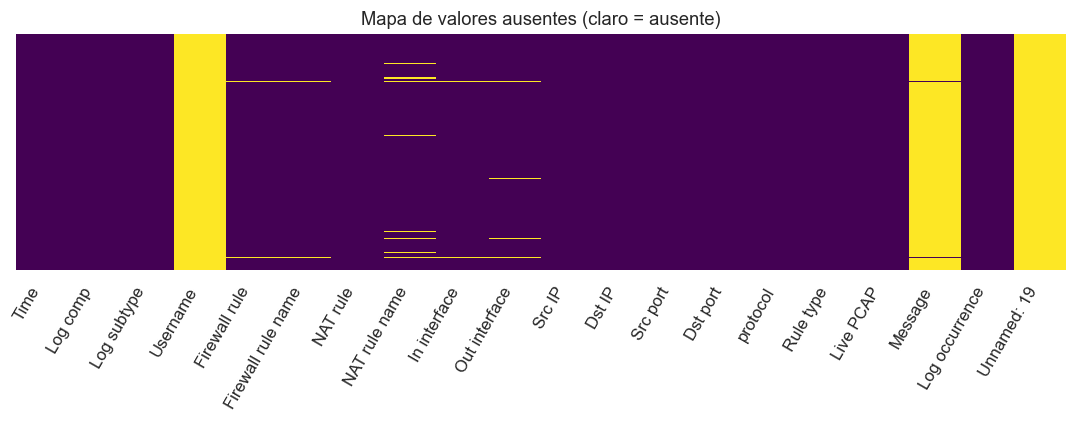

In [4]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores ausentes (claro = ausente)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout(); plt.show()

**Leitura:** `Username` e `Unnamed: 19` são 100% nulas; `Live PCAP` e `Log occurrence` são constantes.
Os nulos em `Firewall rule`, `In/Out interface` e `NAT rule name` **não são aleatórios**: concentram-se nos
2 eventos `Invalid Traffic` (pacotes descartados antes da avaliação de regra) e nos eventos sem NAT aplicado —
portanto são *missing not at random* e serão tratados como categoria explícita `"NONE"`, não imputados.

### 2.a.2 Estatística descritiva das variáveis numéricas

In [5]:
num_cols = ["Src port", "Dst port", "Firewall rule", "NAT rule", "Rule type"]
desc = df[num_cols].describe().T
desc["mediana"] = df[num_cols].median()
desc["variancia"] = df[num_cols].var()
desc["assimetria(skew)"] = df[num_cols].skew()
desc["curtose"] = df[num_cols].kurtosis()
desc["amplitude"] = df[num_cols].max() - df[num_cols].min()
desc["IQR"] = df[num_cols].quantile(.75) - df[num_cols].quantile(.25)
desc["CV(%)"] = (df[num_cols].std() / df[num_cols].mean() * 100).round(1)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,mediana,variancia,assimetria(skew),curtose,amplitude,IQR,CV(%)
Src port,200.0,51726.60,11453.84,0.0,52456.5,54160.5,54614.25,65377.0,54160.5,1.311905e+08,-3.19,11.39,65377.0,2157.75,22.1
Dst port,200.0,250.52,306.72,0.0,53.0,80.0,443.00,3544.0,80.0,9.407765e+04,6.36,66.23,3544.0,390.00,122.4
Firewall rule,198.0,24.97,22.61,2.0,2.0,20.0,48.00,55.0,20.0,5.113600e+02,0.15,-1.84,53.0,46.00,90.6
NAT rule,200.0,13.73,3.27,0.0,15.0,15.0,15.00,15.0,15.0,1.066000e+01,-3.18,10.18,15.0,0.00,23.8
Rule type,200.0,0.99,0.10,0.0,1.0,1.0,1.00,1.0,1.0,1.000000e-02,-9.92,97.46,1.0,0.00,10.1


> **Observação metodológica importante:** `Src port`, `Dst port`, `Firewall rule`, `NAT rule` e `Rule type` são
> numéricos apenas na *representação*. A porta 443 não é "5,5x maior" que a porta 80 — são **variáveis nominais
> codificadas como inteiros**. Estatísticas como a média de `Dst port` são matematicamente válidas e
> semanticamente vazias. Por isso, no pré-processamento, essas colunas são tratadas como categóricas
> (exceto `Src port`, usada apenas via faixa efêmera/privilegiada).

### 2.a.3 Estatística descritiva das variáveis categóricas

In [6]:
cat_cols = ["Log comp", "Log subtype", "Firewall rule name", "NAT rule name",
            "In interface", "Out interface", "Src IP", "Dst IP", "protocol", "Message"]
rows = []
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    rows.append({"variavel": c, "n_categorias": df[c].nunique(dropna=False),
                 "moda": str(vc.index[0]), "freq_moda": int(vc.iloc[0]),
                 "%_moda": round(vc.iloc[0] / len(df) * 100, 1)})
pd.DataFrame(rows).set_index("variavel")

,n_categorias,moda,freq_moda,%_moda
variavel,,,,
Log comp,2,Firewall Rule,198,99.0
Log subtype,2,Allowed,196,98.0
Firewall rule name,11,LAN-2-WAN,72,36.0
NAT rule name,5,Default SNAT IPv4,157,78.5
In interface,4,Port1,124,62.0
Out interface,3,Port2,172,86.0
Src IP,24,192.168.61.233,75,37.5
Dst IP,58,8.8.8.8,68,34.0
protocol,3,TCP,113,56.5


In [7]:
for c in ["Log comp", "Log subtype", "protocol", "Firewall rule name",
          "NAT rule name", "In interface", "Out interface", "Dst port"]:
    print(f"\n=== {c} ===")
    print(pd.concat([df[c].value_counts(dropna=False).rename("freq"),
                     (df[c].value_counts(dropna=False, normalize=True) * 100).round(1).rename("%")],
                    axis=1).to_string())


=== Log comp ===
                 freq     %
Log comp                   
Firewall Rule     198  99.0
Invalid Traffic     2   1.0

=== Log subtype ===
             freq     %
Log subtype            
Allowed       196  98.0
Denied          4   2.0

=== protocol ===
          freq     %
protocol            
TCP        113  56.5
UDP         86  43.0
0            1   0.5

=== Firewall rule name ===
                     freq     %
Firewall rule name             
LAN-2-WAN              72  36.0
WindowsUpdate-2-WAN    35  17.5
DMZ-to-WAN             31  15.5
WebNat                 21  10.5
IT-2-WAN               16   8.0
FileShare-to-WAN        7   3.5
PuplicDNS-2-WAN         6   3.0
PALCERT_Outbound        5   2.5
WAN-2-DNS-DNAT          3   1.5
NaN                     2   1.0
BlockedIP               2   1.0

=== NAT rule name ===
                        freq     %
NAT rule name                     
Default SNAT IPv4        157  78.5
iqrad webserver - DNAT    21  10.5
PublicDNS - SNAT       

### 2.a.4 Visualizações descritivas

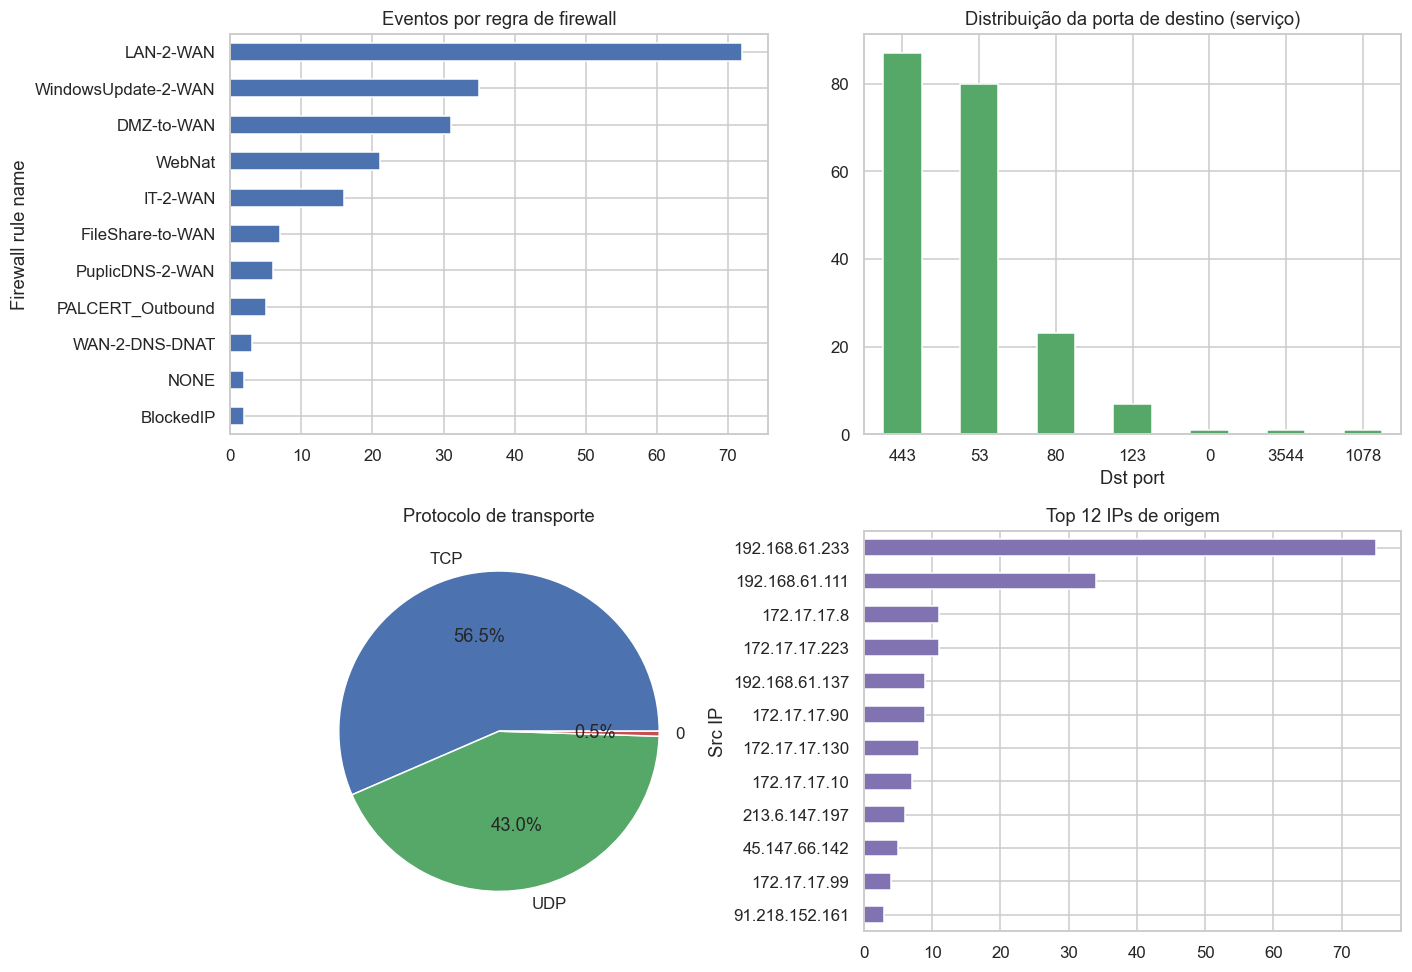

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

df["Firewall rule name"].fillna("NONE").value_counts().plot.barh(ax=ax[0,0], color="#4C72B0")
ax[0,0].set_title("Eventos por regra de firewall"); ax[0,0].invert_yaxis()

df["Dst port"].astype(str).value_counts().plot.bar(ax=ax[0,1], color="#55A868")
ax[0,1].set_title("Distribuição da porta de destino (serviço)")
ax[0,1].tick_params(axis="x", rotation=0)

df["protocol"].value_counts().plot.pie(ax=ax[1,0], autopct="%1.1f%%",
                                       colors=["#4C72B0", "#55A868", "#C44E52"])
ax[1,0].set_ylabel(""); ax[1,0].set_title("Protocolo de transporte")

df["Src IP"].value_counts().head(12).plot.barh(ax=ax[1,1], color="#8172B2")
ax[1,1].set_title("Top 12 IPs de origem"); ax[1,1].invert_yaxis()

plt.tight_layout(); plt.show()

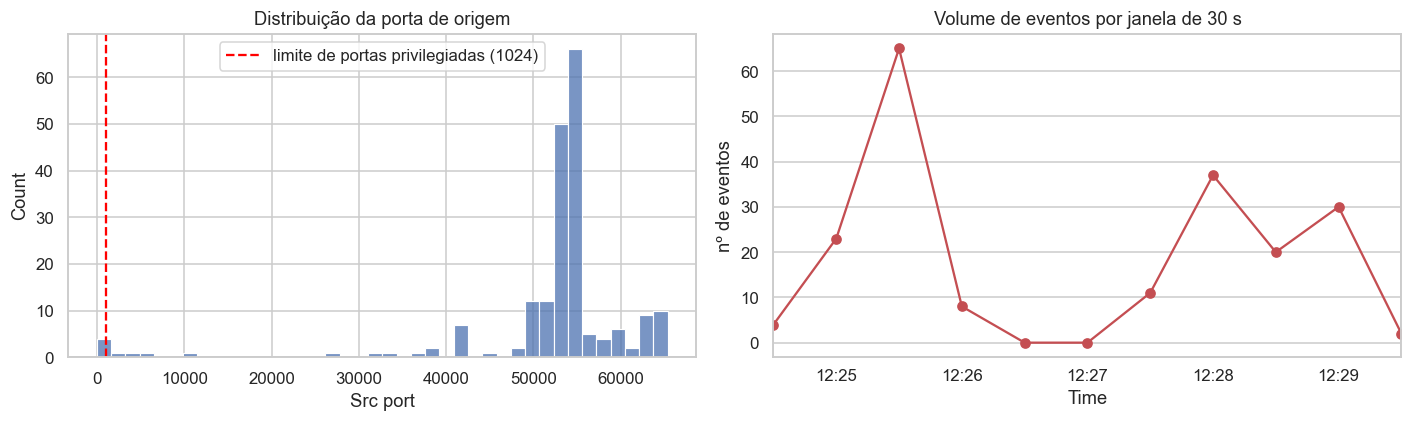

Janela temporal coberta: 2024-07-06 12:24:56 -> 2024-07-06 12:29:34
Duração total: 0 days 00:04:38
Taxa média: 0.72 eventos/s


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["Src port"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].axvline(1024, color="red", ls="--", label="limite de portas privilegiadas (1024)")
ax[0].set_title("Distribuição da porta de origem"); ax[0].legend()

ts = df.set_index("Time").resample("30s").size()
ts.plot(ax=ax[1], marker="o", color="#C44E52")
ax[1].set_title("Volume de eventos por janela de 30 s")
ax[1].set_ylabel("nº de eventos")

plt.tight_layout(); plt.show()

print("Janela temporal coberta:", df["Time"].min(), "->", df["Time"].max())
print("Duração total:", df["Time"].max() - df["Time"].min())
print("Taxa média:", round(len(df) / (df["Time"].max() - df["Time"].min()).total_seconds(), 2), "eventos/s")

protocol,0,TCP,UDP,All
Firewall rule name,,,,
BlockedIP,0,2,0,2
DMZ-to-WAN,0,20,11,31
FileShare-to-WAN,0,2,5,7
IT-2-WAN,0,16,0,16
LAN-2-WAN,0,12,60,72
NONE,1,1,0,2
PALCERT_Outbound,0,5,0,5
PuplicDNS-2-WAN,0,0,6,6
WAN-2-DNS-DNAT,0,0,3,3


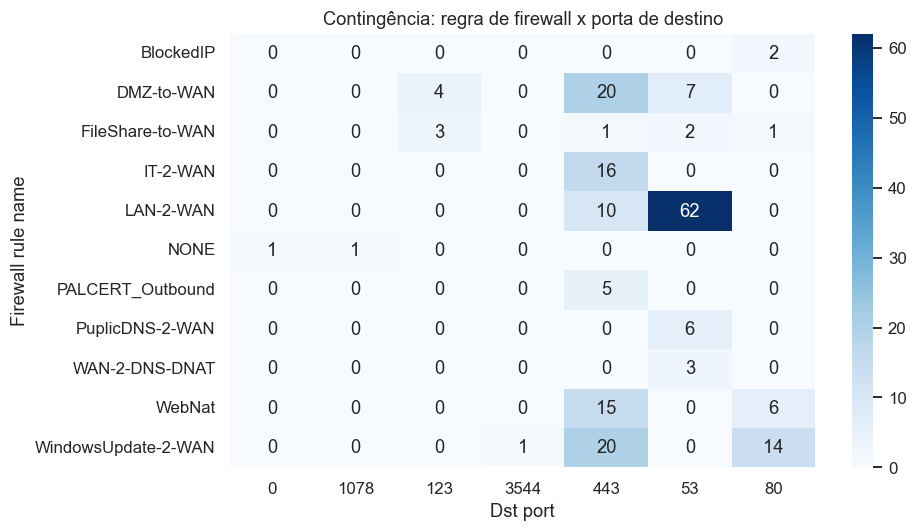

In [10]:
# Tabela de contingência: regra x protocolo (relação entre variáveis categóricas)
ct = pd.crosstab(df["Firewall rule name"].fillna("NONE"), df["protocol"], margins=True)
display(ct)

plt.figure(figsize=(9, 5))
sns.heatmap(pd.crosstab(df["Firewall rule name"].fillna("NONE"), df["Dst port"].astype(str)),
            annot=True, fmt="d", cmap="Blues")
plt.title("Contingência: regra de firewall x porta de destino")
plt.tight_layout(); plt.show()

### 2.a.5 Síntese da estatística descritiva

- **200 eventos** em **~5 minutos** (12:24:56 → 12:29:34), taxa média de ~0,7 evento/s.
- **99%** dos registros são `Firewall Rule` e **98%** são `Allowed`: o dataset é **fortemente desbalanceado**;
  apenas 4 eventos negados (2 pela regra `BlockedIP` e 2 `Invalid Traffic`). Isso reforça a abordagem
  não supervisionada por **detecção de anomalia/ruído**.
- O tráfego concentra-se em três serviços: **443/HTTPS**, **53/DNS** e **80/HTTP** (~95% do total).
- Poucos hosts geram a maior parte do tráfego: `192.168.61.233` (37,5%) e `192.168.61.111` (17%) —
  comportamento típico de estação de trabalho + resolver DNS interno.
- Três segmentos de rede convivem: LAN `192.168.61.0/24` (Port1), DMZ `172.17.17.0/24` (Port3) e WAN (Port2).
- 4 colunas não possuem informação (nulas ou constantes) e serão descartadas.

---
# 2.b) Aplicação dos algoritmos

## 3. Pré-processamento e engenharia de atributos

Nenhum algoritmo de distância funciona diretamente sobre IPs e nomes de regra. Construímos então atributos
com significado de **segurança de rede**:

| Atributo criado | Significado |
|---|---|
| `t_rel` | segundos desde o primeiro evento (ordem temporal) |
| `src_port` | porta de origem (efêmera vs. fixa) |
| `src_ephemeral` | 1 se porta de origem ≥ 1024 |
| `svc` | serviço de destino agrupado (DNS/HTTP/HTTPS/NTP/OTHER) |
| `src_priv`, `dst_priv` | origem/destino em faixa RFC1918 (rede interna) |
| `src_net`, `dst_net` | sub-rede /24 de origem e destino |
| `direction` | interface de entrada → interface de saída (LAN→WAN, WAN→DMZ, ...) |
| `nat_kind` | tipo de NAT aplicado (SNAT / DNAT / NONE) |
| `denied`, `invalid` | evento bloqueado / tráfego inválido |

**Decisão de projeto:** `t_rel` é calculado e usado na análise temporal, mas **não** entra na matriz de
distância da clusterização. Motivo: a janela observada tem apenas 4 min 38 s e o instante do evento é um
índice de coleta, não um comportamento; incluí-lo faz com que eventos vizinhos no tempo fiquem artificialmente
próximos e produz efeitos de borda (os primeiros e últimos registros são marcados como ruído apenas por serem
extremos da janela). Isso foi verificado empiricamente: com `t_rel` na matriz, o ruído do DBSCAN concentrava-se
nos instantes iniciais; sem ele, o ruído passa a corresponder aos eventos semanticamente raros.

In [11]:
def is_private(ip: str) -> int:
    try:
        a, b = int(ip.split(".")[0]), int(ip.split(".")[1])
    except Exception:
        return 0
    return int(a == 10 or (a == 172 and 16 <= b <= 31) or (a == 192 and b == 168))

def net24(ip: str) -> str:
    p = ip.split(".")
    return ".".join(p[:3]) + ".0/24" if len(p) == 4 else "NONE"

SVC = {53: "DNS", 80: "HTTP", 443: "HTTPS", 123: "NTP"}

d = df.copy()

# 1) descarte de colunas sem informação (seleção de características — etapa 1)
inuteis = [c for c in d.columns if d[c].nunique(dropna=False) <= 1]
print("Colunas descartadas por não conterem informação:", inuteis)
d = d.drop(columns=inuteis)

# 2) atributos derivados
d["t_rel"]         = (d["Time"] - d["Time"].min()).dt.total_seconds()
d["src_ephemeral"] = (d["Src port"] >= 1024).astype(int)
d["svc"]           = d["Dst port"].map(SVC).fillna("OTHER")
d["src_priv"]      = d["Src IP"].apply(is_private)
d["dst_priv"]      = d["Dst IP"].apply(is_private)
d["src_net"]       = d["Src IP"].apply(net24)
d["dst_net"]       = d["Dst IP"].apply(net24)
d["in_if"]         = d["In interface"].fillna("NONE")
d["out_if"]        = d["Out interface"].fillna("NONE")
d["direction"]     = d["in_if"] + "->" + d["out_if"]
d["rule"]          = d["Firewall rule name"].fillna("NONE")
d["nat_rule"]      = d["NAT rule name"].fillna("NONE")
d["nat_kind"]      = np.select(
    [d["nat_rule"].str.contains("DNAT"), d["nat_rule"].str.contains("SNAT")],
    ["DNAT", "SNAT"], default="NONE")
d["denied"]        = (d["Log subtype"] == "Denied").astype(int)
d["invalid"]       = (d["Log comp"] == "Invalid Traffic").astype(int)
d["src_port"]      = d["Src port"]

d[["Time", "t_rel", "rule", "direction", "nat_kind", "svc", "protocol",
   "src_net", "dst_net", "src_priv", "dst_priv", "denied"]].head(8)

Colunas descartadas por não conterem informação: ['Username', 'Live PCAP', 'Log occurrence', 'Unnamed: 19']


,Time,t_rel,rule,direction,nat_kind,svc,protocol,src_net,dst_net,src_priv,dst_priv,denied
0,2024-07-06 12:29:34,278.0,WebNat,Port2->Port3,DNAT,HTTPS,TCP,45.147.66.0/24,82.213.48.0/24,0,0,0
1,2024-07-06 12:29:30,274.0,DMZ-to-WAN,Port3->Port2,SNAT,HTTPS,TCP,172.17.17.0/24,10.101.6.0/24,1,1,0
2,2024-07-06 12:29:29,273.0,LAN-2-WAN,Port1->Port2,SNAT,HTTPS,TCP,192.168.61.0/24,3.72.193.0/24,1,0,0
3,2024-07-06 12:29:29,273.0,WebNat,Port2->Port3,DNAT,HTTPS,TCP,45.147.66.0/24,82.213.48.0/24,0,0,0
4,2024-07-06 12:29:29,273.0,DMZ-to-WAN,Port3->Port2,SNAT,HTTPS,TCP,172.17.17.0/24,23.196.143.0/24,1,0,0
5,2024-07-06 12:29:29,273.0,IT-2-WAN,Port1->Port2,SNAT,HTTPS,TCP,192.168.61.0/24,104.46.162.0/24,1,0,0
6,2024-07-06 12:29:29,273.0,WebNat,Port2->Port3,DNAT,HTTPS,TCP,91.218.152.0/24,82.213.48.0/24,0,0,0
7,2024-07-06 12:29:28,272.0,LAN-2-WAN,Port1->Port2,SNAT,HTTPS,TCP,192.168.61.0/24,147.182.140.0/24,1,0,0


In [12]:
# 3) matriz de atributos: one-hot nas nominais + padronização nas contínuas
# NOTA: t_rel NÃO entra na matriz de distância (ver justificativa na célula de texto acima);
#       ele é usado apenas na análise descritiva/temporal.
cat_feats = ["rule", "nat_kind", "direction", "protocol", "svc", "src_net", "dst_net"]
num_feats = ["src_port"]
bin_feats = ["src_ephemeral", "src_priv", "dst_priv", "denied", "invalid"]

X_cat = pd.get_dummies(d[cat_feats], prefix=cat_feats).astype(float)
X_raw = pd.concat([d[num_feats + bin_feats].astype(float), X_cat], axis=1)

print("Matriz antes da seleção de características:", X_raw.shape)
X_raw.head(3)

Matriz antes da seleção de características: (200, 100)


,src_port,src_ephemeral,src_priv,dst_priv,denied,invalid,rule_BlockedIP,rule_DMZ-to-WAN,rule_FileShare-to-WAN,rule_IT-2-WAN,...,dst_net_65.49.2.0/24,dst_net_72.246.151.0/24,dst_net_72.52.87.0/24,dst_net_74.82.60.0/24,dst_net_8.8.4.0/24,dst_net_8.8.8.0/24,dst_net_82.213.48.0/24,dst_net_82.213.6.0/24,dst_net_95.100.173.0/24,dst_net_95.100.175.0/24
0,4036.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,52907.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,53382.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Técnicas de seleção de características

Duas técnicas complementares:

1. **VarianceThreshold** — remove *dummies* quase constantes (categorias presentes em <1% dos registros não
   separam grupos; apenas adicionam dimensão e ruído).
2. **Filtro por correlação** — remove atributos redundantes (|ρ| > 0,95), que inflam artificialmente o peso de
   uma mesma informação na distância euclidiana (ex.: `protocol_UDP` e `svc_DNS` carregam quase o mesmo sinal).

Ao final (seção 9) avaliamos a **informação mútua** de cada atributo em relação aos clusters obtidos, como
medida *a posteriori* de relevância.

In [13]:
# --- 4.1 VarianceThreshold ---
vt = VarianceThreshold(threshold=0.01)   # em dummies: p(1-p) > 0.01 => categoria em >~1% dos casos
vt.fit(X_raw)
keep_vt = X_raw.columns[vt.get_support()]
print(f"Removidos por variância quase nula ({X_raw.shape[1] - len(keep_vt)}):")
print(sorted(set(X_raw.columns) - set(keep_vt)))
X_vt = X_raw[keep_vt]

# --- 4.2 filtro de correlação ---
corr = X_vt.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if (upper[c] > 0.95).any()]
print(f"\nRemovidos por redundância (|rho|>0.95) ({len(drop_corr)}): {drop_corr}")

X_sel = X_vt.drop(columns=drop_corr)
print("\nMatriz final de atributos:", X_sel.shape)

X = StandardScaler().fit_transform(X_sel)
feat_names = list(X_sel.columns)

Removidos por variância quase nula (56):
['direction_NONE->NONE', 'direction_Port1->NONE', 'dst_net_0.0.0.0/24', 'dst_net_104.46.162.0/24', 'dst_net_13.69.109.0/24', 'dst_net_13.95.31.0/24', 'dst_net_147.182.140.0/24', 'dst_net_152.199.19.0/24', 'dst_net_173.194.76.0/24', 'dst_net_184.30.17.0/24', 'dst_net_184.30.26.0/24', 'dst_net_185.153.163.0/24', 'dst_net_192.168.50.0/24', 'dst_net_20.190.181.0/24', 'dst_net_20.42.72.0/24', 'dst_net_20.54.110.0/24', 'dst_net_205.251.194.0/24', 'dst_net_205.251.197.0/24', 'dst_net_213.244.72.0/24', 'dst_net_213.6.25.0/24', 'dst_net_216.58.212.0/24', 'dst_net_23.196.143.0/24', 'dst_net_23.32.238.0/24', 'dst_net_3.72.193.0/24', 'dst_net_34.209.8.0/24', 'dst_net_40.126.53.0/24', 'dst_net_40.81.120.0/24', 'dst_net_44.237.175.0/24', 'dst_net_52.109.77.0/24', 'dst_net_52.123.159.0/24', 'dst_net_52.167.161.0/24', 'dst_net_52.177.176.0/24', 'dst_net_52.191.219.0/24', 'dst_net_52.26.21.0/24', 'dst_net_64.62.219.0/24', 'dst_net_65.49.2.0/24', 'dst_net_72.246.

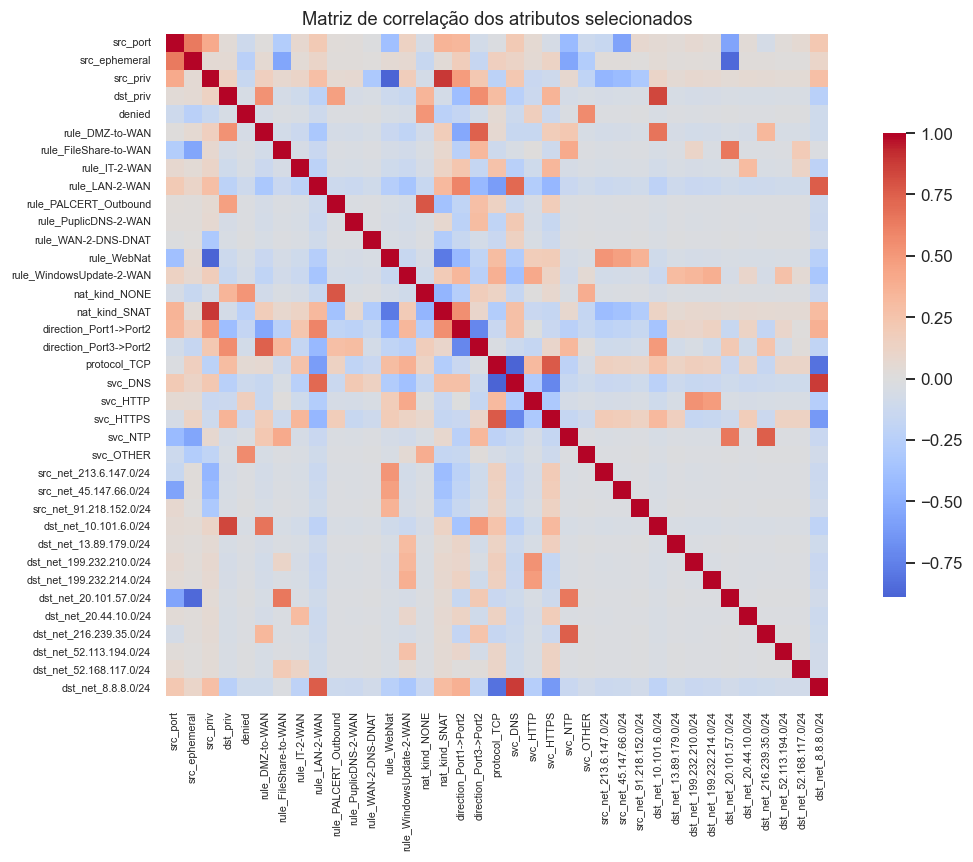

In [14]:
plt.figure(figsize=(11, 8))
sns.heatmap(X_sel.corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .7}, xticklabels=True, yticklabels=True)
plt.title("Matriz de correlação dos atributos selecionados")
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

## 5. Análise de Componentes Principais (PCA)

**Justificativa:** após o *one-hot encoding* temos dezenas de dimensões esparsas para apenas 200 amostras
(razão amostra/dimensão desfavorável). Nessa situação as distâncias euclidianas tendem a se concentrar
(*curse of dimensionality*), degradando K-Means e — sobretudo — DBSCAN. O PCA:

- descorrelaciona os atributos e concentra a variância em poucos eixos;
- fornece um espaço de **2 dimensões** para visualização;
- será usado como **espaço de trabalho da clusterização** (componentes que retêm 90% da variância).

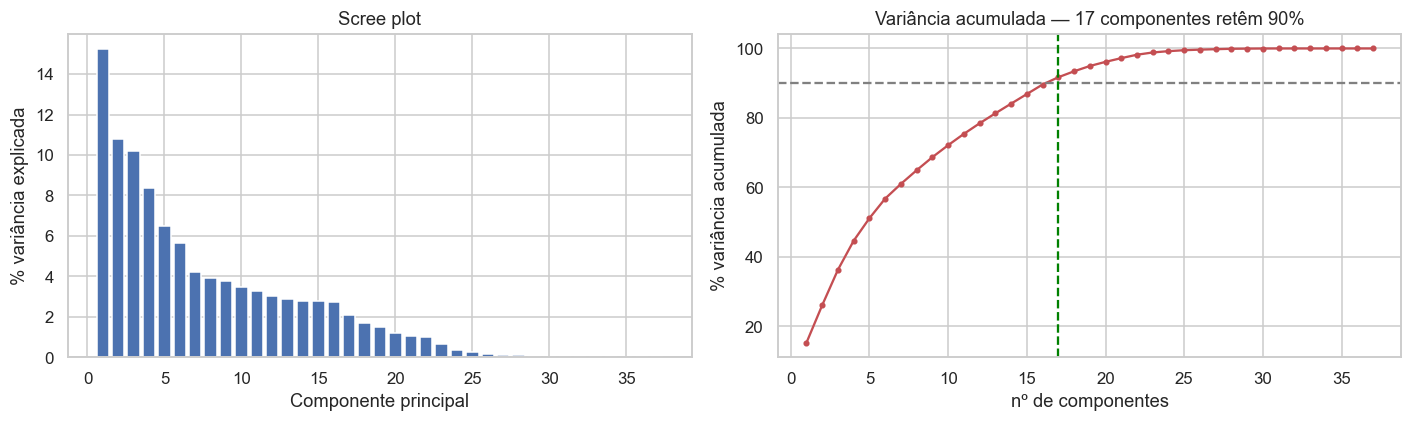

Dimensionalidade original: 37  ->  espaço PCA(90%): 17 componentes
Variância dos 5 primeiros PCs (%): [15.23 10.81 10.21  8.36  6.49]


In [15]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.argmax(cum >= 0.90) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, len(evr) + 1), evr * 100, color="#4C72B0")
ax[0].set_xlabel("Componente principal"); ax[0].set_ylabel("% variância explicada")
ax[0].set_title("Scree plot")

ax[1].plot(range(1, len(cum) + 1), cum * 100, marker="o", ms=3, color="#C44E52")
ax[1].axhline(90, ls="--", color="gray"); ax[1].axvline(n90, ls="--", color="green")
ax[1].set_xlabel("nº de componentes"); ax[1].set_ylabel("% variância acumulada")
ax[1].set_title(f"Variância acumulada — {n90} componentes retêm 90%")
plt.tight_layout(); plt.show()

print(f"Dimensionalidade original: {X.shape[1]}  ->  espaço PCA(90%): {n90} componentes")
print("Variância dos 5 primeiros PCs (%):", (evr[:5] * 100).round(2))

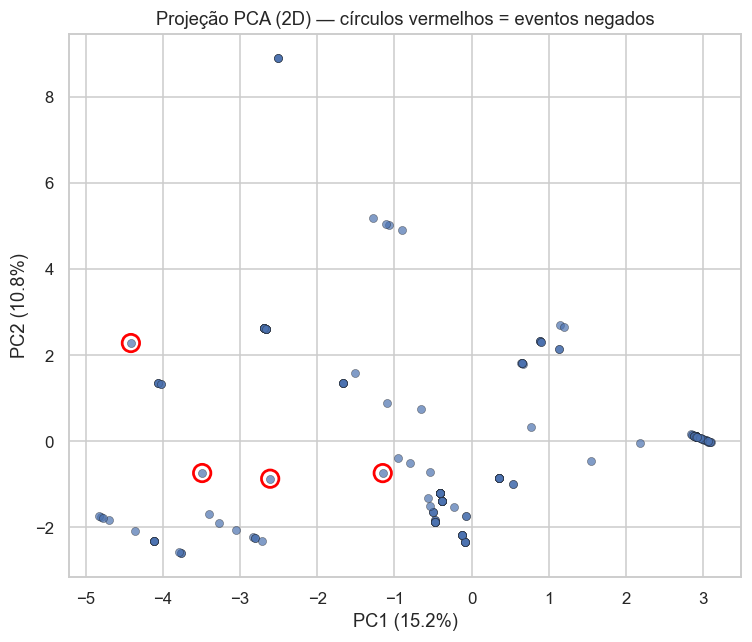

In [16]:
pca90 = PCA(n_components=n90, random_state=RANDOM_STATE)
Xp = pca90.fit_transform(X)              # espaço usado na clusterização
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca2.fit_transform(X)               # espaço usado na visualização

plt.figure(figsize=(7, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=28, c="#4C72B0", alpha=.7, edgecolor="k", linewidth=.3)
for i in np.where(d["denied"].values == 1)[0]:
    plt.scatter(X2[i, 0], X2[i, 1], s=130, facecolor="none", edgecolor="red", linewidth=1.8)
plt.title("Projeção PCA (2D) — círculos vermelhos = eventos negados")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout(); plt.show()

Atributos com maior carga absoluta em PC1:


,PC1,PC2
dst_net_8.8.8.0/24,0.342,0.070
svc_DNS,0.342,0.091
rule_LAN-2-WAN,0.336,-0.010
protocol_TCP,-0.303,-0.216
direction_Port1->Port2,0.300,-0.224
nat_kind_SNAT,0.274,0.136
svc_HTTPS,-0.259,-0.102
src_priv,0.239,0.170


Atributos com maior carga absoluta em PC2:


,PC1,PC2
direction_Port3->Port2,-0.145,0.389
svc_NTP,-0.057,0.319
rule_DMZ-to-WAN,-0.113,0.283
dst_net_20.101.57.0/24,-0.055,0.274
src_ephemeral,0.076,-0.259
rule_FileShare-to-WAN,-0.037,0.235
direction_Port1->Port2,0.300,-0.224
protocol_TCP,-0.303,-0.216


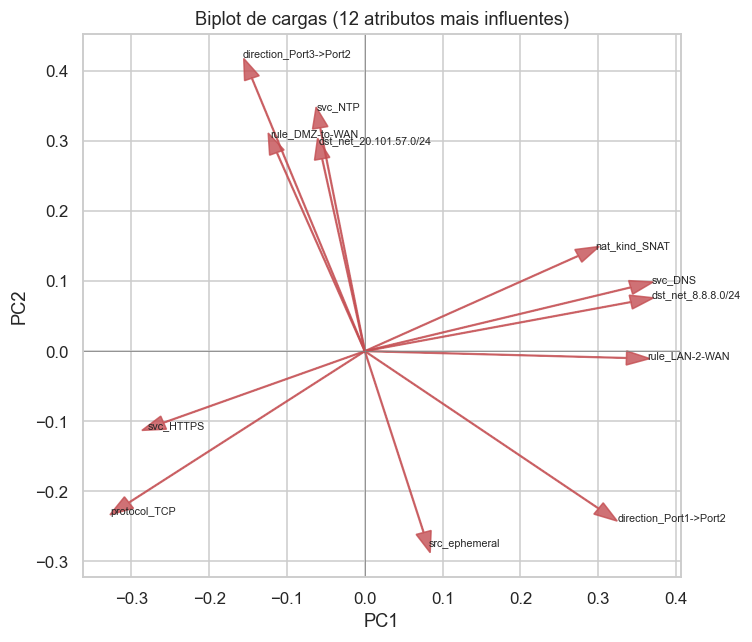

In [17]:
# Cargas (loadings): quais atributos formam PC1 e PC2
load = pd.DataFrame(pca2.components_.T, index=feat_names, columns=["PC1", "PC2"])
print("Atributos com maior carga absoluta em PC1:")
display(load.reindex(load["PC1"].abs().sort_values(ascending=False).index).head(8).round(3))
print("Atributos com maior carga absoluta em PC2:")
display(load.reindex(load["PC2"].abs().sort_values(ascending=False).index).head(8).round(3))

plt.figure(figsize=(7, 6))
sel = load.loc[load.abs().max(axis=1).sort_values(ascending=False).head(12).index]
for name, r in sel.iterrows():
    plt.arrow(0, 0, r["PC1"], r["PC2"], head_width=.02, color="#C44E52", alpha=.8)
    plt.text(r["PC1"] * 1.08, r["PC2"] * 1.08, name, fontsize=7)
plt.axhline(0, color="gray", lw=.5); plt.axvline(0, color="gray", lw=.5)
plt.title("Biplot de cargas (12 atributos mais influentes)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

**Interpretação:** PC1 e PC2 são dominados pelos atributos que descrevem *de onde para onde* o tráfego vai
(`direction_*`, `src_net_*`, `rule_*`) e *qual serviço* é acessado (`svc_*`, `protocol_UDP`). Ou seja, a maior
fonte de variância do log é a combinação **segmento de rede × serviço**, o que já antecipa a natureza dos clusters.

## 6. K-Means

**Justificativa e cuidados:** o K-Means minimiza a inércia intra-cluster assumindo grupos aproximadamente
esféricos e de tamanho similar — hipótese razoável para "perfis de tráfego" repetitivos, mas frágil diante de
eventos raros (que ele é obrigado a alocar em algum cluster). Aplicamos sobre o espaço PCA(90%) e avaliamos
*k* por **Elbow (inércia)**, **Silhouette**, **Davies-Bouldin** e **Calinski-Harabasz**.

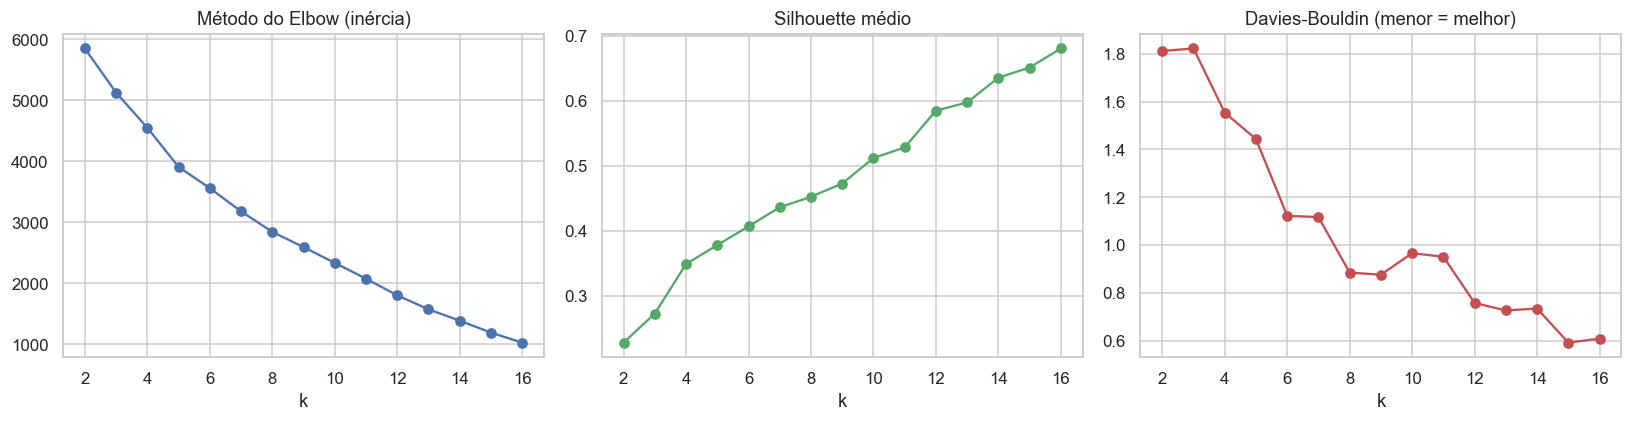

,inercia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,5852.3,0.227,1.812,31.6
3,5127.9,0.272,1.822,31.9
4,4551.5,0.349,1.554,32.1
5,3908.6,0.378,1.443,35.9
6,3560.3,0.407,1.122,35.2
7,3179.3,0.436,1.117,36.5
8,2843.1,0.452,0.884,38.0
9,2592.8,0.473,0.876,38.6
10,2334.6,0.512,0.966,40.3


k pelo joelho da inércia (Elbow): 7
k pelo maior Silhouette na faixa testada: 16


In [18]:
ks = range(2, 17)
inertia, sil, dbi, chi = [], [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xp)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xp, km.labels_))
    dbi.append(davies_bouldin_score(Xp, km.labels_))
    chi.append(calinski_harabasz_score(Xp, km.labels_))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ks, inertia, marker="o"); ax[0].set_title("Método do Elbow (inércia)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, marker="o", color="#55A868"); ax[1].set_title("Silhouette médio"); ax[1].set_xlabel("k")
ax[2].plot(ks, dbi, marker="o", color="#C44E52"); ax[2].set_title("Davies-Bouldin (menor = melhor)"); ax[2].set_xlabel("k")
for a in ax: a.grid(True)
plt.tight_layout(); plt.show()

tab_k = pd.DataFrame({"k": list(ks), "inercia": np.round(inertia, 1), "silhouette": np.round(sil, 3),
                      "davies_bouldin": np.round(dbi, 3),
                      "calinski_harabasz": np.round(chi, 1)}).set_index("k")
display(tab_k)

# --- escolha de k pelo "joelho" da curva de inércia (método Kneedle: maior distância à corda) ---
xk = np.array(list(ks), float); yk = np.array(inertia, float)
xn = (xk - xk.min()) / (xk.max() - xk.min()); yn = (yk - yk.min()) / (yk.max() - yk.min())
p1, p2 = np.array([xn[0], yn[0]]), np.array([xn[-1], yn[-1]])
v = (p2 - p1) / np.linalg.norm(p2 - p1)
pts = np.c_[xn, yn]; proj = np.outer((pts - p1) @ v, v) + p1
K_BEST = int(list(ks)[int(np.argmax(np.linalg.norm(pts - proj, axis=1)))])

print("k pelo joelho da inércia (Elbow):", K_BEST)
print("k pelo maior Silhouette na faixa testada:", int(tab_k["silhouette"].idxmax()))

> **Por que NÃO usar o máximo do Silhouette aqui?** A tabela acima mostra que o Silhouette **cresce
> monotonicamente** com *k* em toda a faixa testada. Isso é um artefato conhecido de espaços *one-hot*: os
> eventos se organizam em muitos grupos minúsculos e internamente quase idênticos (combinações repetidas de
> regra/rota/serviço), e cada subdivisão adicional aumenta a coesão medida sem revelar estrutura nova. Usar o
> argmax do Silhouette levaria a *k* = limite da faixa (um cluster por combinação de categorias), o que é
> tecnicamente "ótimo" e analiticamente inútil.
>
> Adotamos portanto o **joelho da curva de inércia** (método Kneedle, aplicado de forma objetiva pela máxima
> distância à corda que une os extremos da curva), com o Silhouette e o Davies-Bouldin como métricas de
> **verificação** — não de seleção. O valor obtido é também o que produz clusters interpretáveis em termos de
> perfis operacionais de tráfego, como mostra a tabela de perfis a seguir.

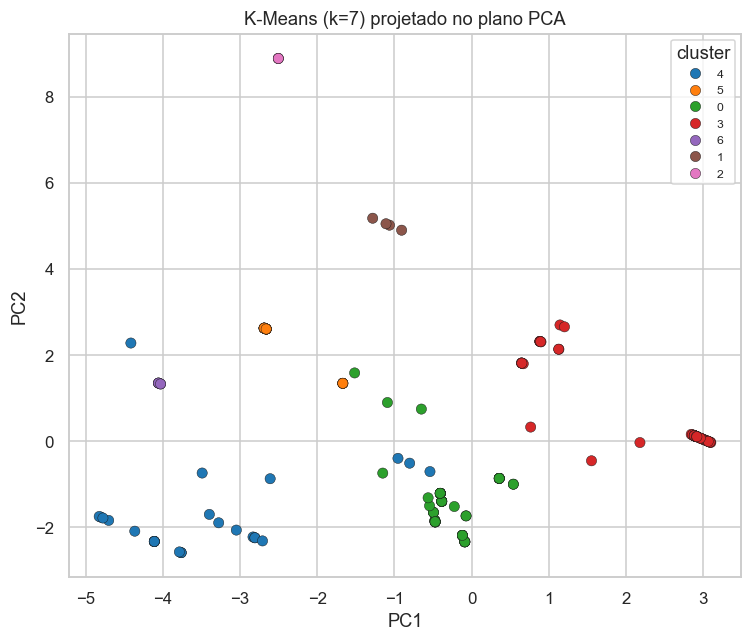

km
0    64
1     4
2     3
3    77
4    27
5    20
6     5


In [19]:
kmeans = KMeans(n_clusters=K_BEST, n_init=50, random_state=RANDOM_STATE).fit(Xp)
d["km"] = kmeans.labels_

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=d["km"].astype(str), palette="tab10",
                s=45, edgecolor="k", linewidth=.3)
plt.title(f"K-Means (k={K_BEST}) projetado no plano PCA")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(title="cluster", fontsize=8)
plt.tight_layout(); plt.show()

print(d["km"].value_counts().sort_index().rename("nº eventos").to_string())

In [20]:
def perfil(col):
    "Perfil interpretável de cada cluster."
    g = d.groupby(col)
    return pd.DataFrame({
        "n": g.size(),
        "%": (g.size() / len(d) * 100).round(1),
        "regra_dominante": g["rule"].agg(lambda s: s.value_counts().index[0]),
        "direcao_dominante": g["direction"].agg(lambda s: s.value_counts().index[0]),
        "servico_dominante": g["svc"].agg(lambda s: s.value_counts().index[0]),
        "proto_dominante": g["protocol"].agg(lambda s: s.value_counts().index[0]),
        "nat": g["nat_kind"].agg(lambda s: s.value_counts().index[0]),
        "src_net_dominante": g["src_net"].agg(lambda s: s.value_counts().index[0]),
        "n_src_ips": g["Src IP"].nunique(),
        "n_dst_ips": g["Dst IP"].nunique(),
        "n_negados": g["denied"].sum(),
    })

print(f"=== Perfil dos clusters K-Means (k={K_BEST}) ===")
perfil("km")

=== Perfil dos clusters K-Means (k=7) ===


,n,%,regra_dominante,direcao_dominante,servico_dominante,proto_dominante,nat,src_net_dominante,n_src_ips,n_dst_ips,n_negados
km,,,,,,,,,,,
0,64,32.0,WindowsUpdate-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,4,37,1
1,4,2.0,DMZ-to-WAN,Port3->Port2,NTP,UDP,SNAT,172.17.17.0/24,1,1,0
2,3,1.5,FileShare-to-WAN,Port3->Port2,NTP,UDP,SNAT,172.17.17.0/24,1,1,0
3,77,38.5,LAN-2-WAN,Port1->Port2,DNS,UDP,SNAT,192.168.61.0/24,8,9,0
4,27,13.5,WebNat,Port2->Port3,HTTPS,TCP,DNAT,213.6.147.0/24,13,5,3
5,20,10.0,DMZ-to-WAN,Port3->Port2,HTTPS,TCP,SNAT,172.17.17.0/24,3,5,0
6,5,2.5,PALCERT_Outbound,Port3->Port2,HTTPS,TCP,NONE,172.17.17.0/24,2,1,0


## 7. Clusterização Hierárquica (aglomerativa, ligação de Ward)

**Justificativa:** com n=200 o custo O(n²) é irrelevante e ganhamos o **dendrograma**, que expõe a hierarquia
dos perfis de tráfego (p.ex. "tudo que sai da LAN" subdividindo-se em DNS e HTTPS). Usamos a ligação **Ward**
porque minimiza a variância intra-grupo — critério compatível com o do K-Means, o que permite comparar os dois
métodos de forma justa. O **coeficiente cofenético** mede o quanto o dendrograma preserva as distâncias originais.

In [21]:
Z = linkage(Xp, method="ward")
print("Coeficiente cofenético (Ward):", round(cophenet(Z, pdist(Xp))[0], 3))

for m in ["single", "complete", "average", "ward"]:
    Zm = linkage(Xp, method=m)
    print(f"  ligação {m:9s} -> cofenético = {cophenet(Zm, pdist(Xp))[0]:.3f}")

Coeficiente cofenético (Ward): 0.61
  ligação single    -> cofenético = 0.901
  ligação complete  -> cofenético = 0.844
  ligação average   -> cofenético = 0.958
  ligação ward      -> cofenético = 0.610


> **Leitura honesta do coeficiente cofenético:** a ligação `average` obtém o **maior** valor, e `ward` o menor.
> Isso não invalida a escolha: o cofenético mede fidelidade da *árvore* às distâncias originais, não a utilidade
> da partição. `single`/`average` maximizam essa fidelidade produzindo o efeito de *chaining* — um cluster
> gigante mais vários grupos de 1–3 pontos —, o que não gera perfis de tráfego utilizáveis. `Ward` sacrifica
> fidelidade métrica em favor de grupos compactos e balanceados, e usa o mesmo critério de variância do K-Means,
> tornando a comparação entre os dois algoritmos legítima. A escolha é, portanto, deliberada.

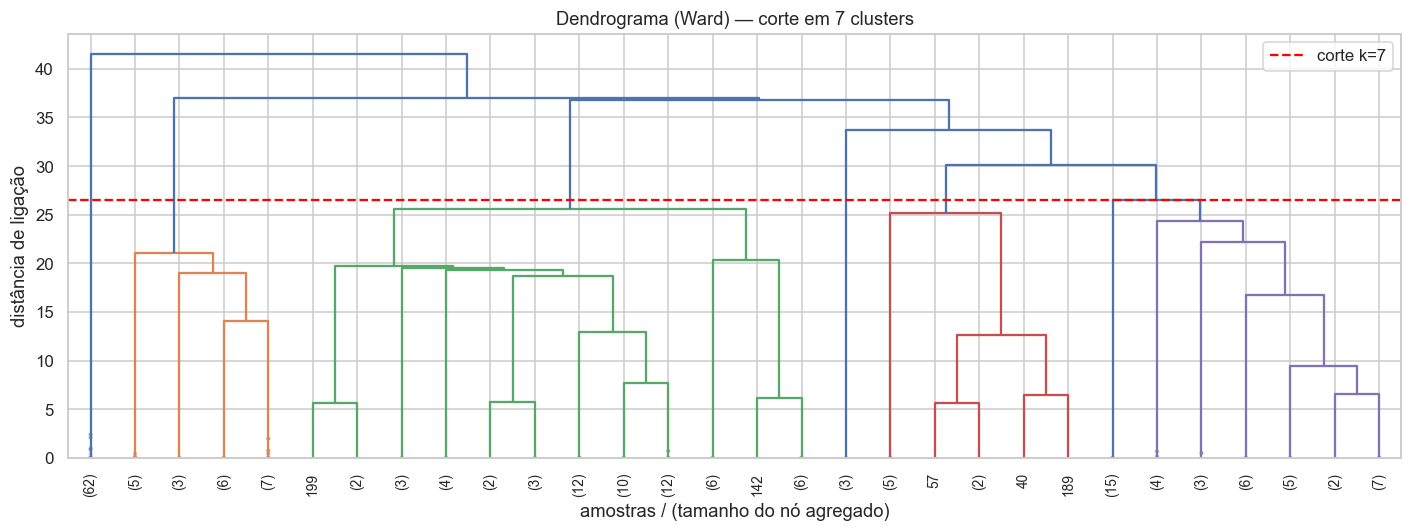

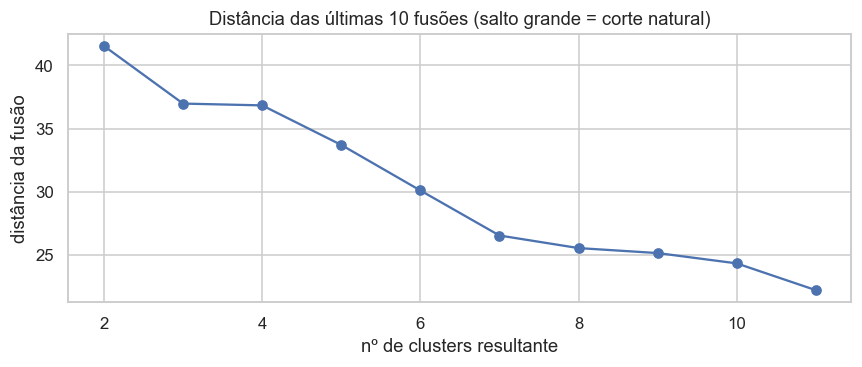

In [22]:
plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=Z[-(K_BEST - 1), 2])
plt.title(f"Dendrograma (Ward) — corte em {K_BEST} clusters")
plt.xlabel("amostras / (tamanho do nó agregado)"); plt.ylabel("distância de ligação")
plt.axhline(Z[-(K_BEST - 1), 2], color="red", ls="--", label=f"corte k={K_BEST}")
plt.legend(); plt.tight_layout(); plt.show()

# Saltos de fusão: indicam o número "natural" de grupos
last = Z[-10:, 2][::-1]
plt.figure(figsize=(8, 3.5))
plt.plot(range(2, 12), last, marker="o")
plt.title("Distância das últimas 10 fusões (salto grande = corte natural)")
plt.xlabel("nº de clusters resultante"); plt.ylabel("distância da fusão")
plt.grid(True); plt.tight_layout(); plt.show()

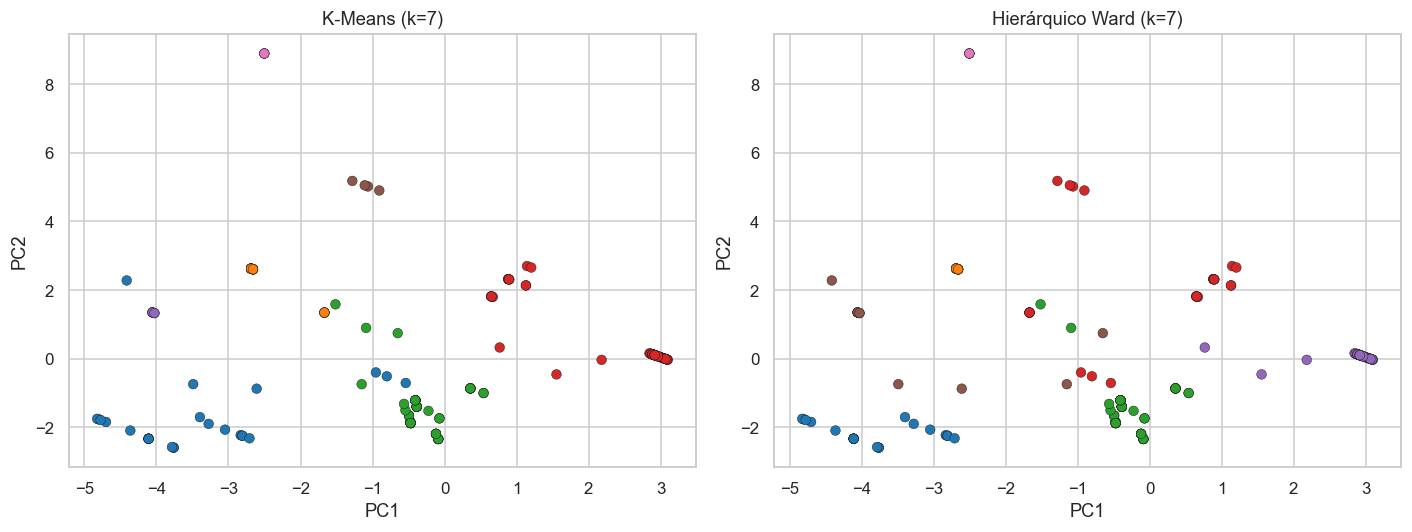

=== Perfil dos clusters hierárquicos ===


,n,%,regra_dominante,direcao_dominante,servico_dominante,proto_dominante,nat,src_net_dominante,n_src_ips,n_dst_ips,n_negados
hc,,,,,,,,,,,
0,62,31.0,WindowsUpdate-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,4,35,0
1,27,13.5,DMZ-to-WAN,Port3->Port2,DNS,UDP,SNAT,172.17.17.0/24,6,12,0
2,10,5.0,PALCERT_Outbound,Port3->Port2,HTTPS,TCP,NONE,172.17.17.0/24,6,5,4
3,62,31.0,LAN-2-WAN,Port1->Port2,DNS,UDP,SNAT,192.168.61.0/24,5,4,0
4,3,1.5,FileShare-to-WAN,Port3->Port2,NTP,UDP,SNAT,172.17.17.0/24,1,1,0
5,21,10.5,WebNat,Port2->Port3,HTTPS,TCP,DNAT,213.6.147.0/24,8,1,0
6,15,7.5,DMZ-to-WAN,Port3->Port2,HTTPS,TCP,SNAT,172.17.17.0/24,2,1,0



Tabela de correspondência K-Means x Hierárquico:


Hierárquico,0,1,2,3,4,5,6
K-Means,,,,,,,
0,62,0,2,0,0,0,0
1,0,4,0,0,0,0,0
2,0,0,0,0,3,0,0
3,0,15,0,62,0,0,0
4,0,3,3,0,0,21,0
5,0,5,0,0,0,0,15
6,0,0,5,0,0,0,0


In [23]:
hc = AgglomerativeClustering(n_clusters=K_BEST, linkage="ward").fit(Xp)
d["hc"] = hc.labels_

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=d["km"].astype(str), palette="tab10",
                s=40, edgecolor="k", linewidth=.3, ax=ax[0], legend=False)
ax[0].set_title(f"K-Means (k={K_BEST})")
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=d["hc"].astype(str), palette="tab10",
                s=40, edgecolor="k", linewidth=.3, ax=ax[1], legend=False)
ax[1].set_title(f"Hierárquico Ward (k={K_BEST})")
for a in ax:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

print("=== Perfil dos clusters hierárquicos ===")
display(perfil("hc"))
print("\nTabela de correspondência K-Means x Hierárquico:")
display(pd.crosstab(d["km"], d["hc"], rownames=["K-Means"], colnames=["Hierárquico"]))

## 8. DBSCAN

**Justificativa:** é o algoritmo mais alinhado ao objetivo de segurança. Ele (i) não exige *k*, (ii) encontra
clusters de forma arbitrária por densidade e (iii) **rotula como ruído (-1)** os pontos que não pertencem a
nenhuma região densa — que, em um log de firewall, são precisamente os **eventos atípicos** candidatos a
investigação.

**Parâmetros:** `min_samples = 4`, seguindo a heurística `min_samples ≈ ln(n)` (ln 200 ≈ 5,3; adotamos 4 para
não exigir densidade alta demais num dataset pequeno e fragmentado — a heurística alternativa `2·dim` produziria
`min_samples = 34`, que aqui colapsa tudo em um único cluster, como verificamos). `eps` é escolhido pelo
**gráfico de k-distâncias**, no ponto de inflexão ("joelho"), detectado objetivamente pela máxima distância à
reta que une os extremos da curva.

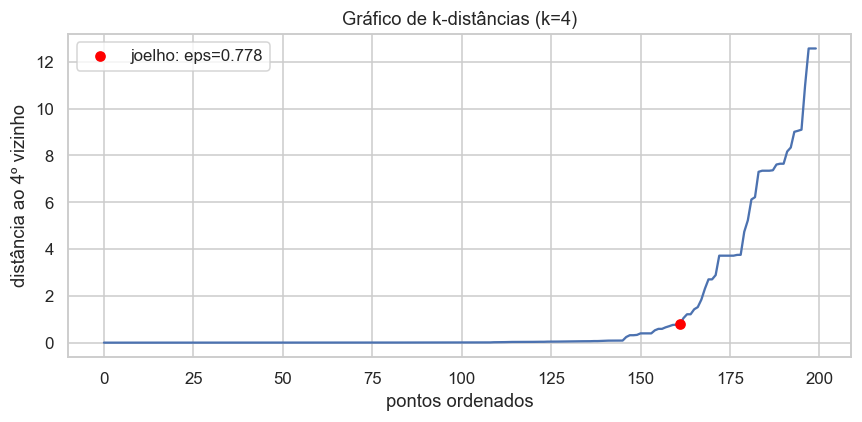

min_samples = 4 | eps estimado = 0.778


In [24]:
min_samples = 4
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xp)
dist, _ = nn.kneighbors(Xp)
kdist = np.sort(dist[:, -1])

x = np.arange(len(kdist)); y = kdist
p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
vec = (p2 - p1) / np.linalg.norm(p2 - p1)
proj = np.outer((np.c_[x, y] - p1) @ vec, vec) + p1
knee = int(np.argmax(np.linalg.norm(np.c_[x, y] - proj, axis=1)))
EPS = float(round(kdist[knee], 3))
if EPS <= 0:   # salvaguarda: haveria pontos idênticos no joelho
    EPS = float(round(kdist[kdist > 0][0], 3))

plt.figure(figsize=(8, 4))
plt.plot(kdist, color="#4C72B0")
plt.scatter([knee], [kdist[knee]], color="red", zorder=5, label=f"joelho: eps={EPS}")
plt.title(f"Gráfico de k-distâncias (k={min_samples})")
plt.xlabel("pontos ordenados"); plt.ylabel(f"distância ao {min_samples}º vizinho")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print("min_samples =", min_samples, "| eps estimado =", EPS)

In [25]:
# Varredura de sensibilidade em eps (mostra que a escolha não é frágil)
res = []
for e in np.round(np.linspace(EPS * 0.4, EPS * 2.5, 16), 3):
    lab = DBSCAN(eps=e, min_samples=min_samples).fit_predict(Xp)
    nc = len(set(lab) - {-1}); nr = int((lab == -1).sum())
    s = (silhouette_score(Xp[lab != -1], lab[lab != -1])
         if nc > 1 and (lab != -1).sum() > nc else np.nan)
    res.append({"eps": e, "n_clusters": nc, "n_ruido": nr, "%_ruido": round(nr / len(lab) * 100, 1),
                "silhouette(sem ruido)": None if np.isnan(s) else round(s, 3)})
display(pd.DataFrame(res))

,eps,n_clusters,n_ruido,%_ruido,silhouette(sem ruido)
0,0.311,14,50,25.0,0.973
1,0.420,15,46,23.0,0.972
2,0.529,15,45,22.5,0.969
3,0.638,15,43,21.5,0.964
4,0.747,16,37,18.5,0.959
5,0.856,16,35,17.5,0.955
6,0.965,16,35,17.5,0.955
7,1.074,16,33,16.5,0.943
8,1.183,16,32,16.0,0.942
9,1.291,16,32,16.0,0.942


DBSCAN(eps=0.778, min_samples=4) -> 16 clusters + 36 pontos de ruído (18.0%)


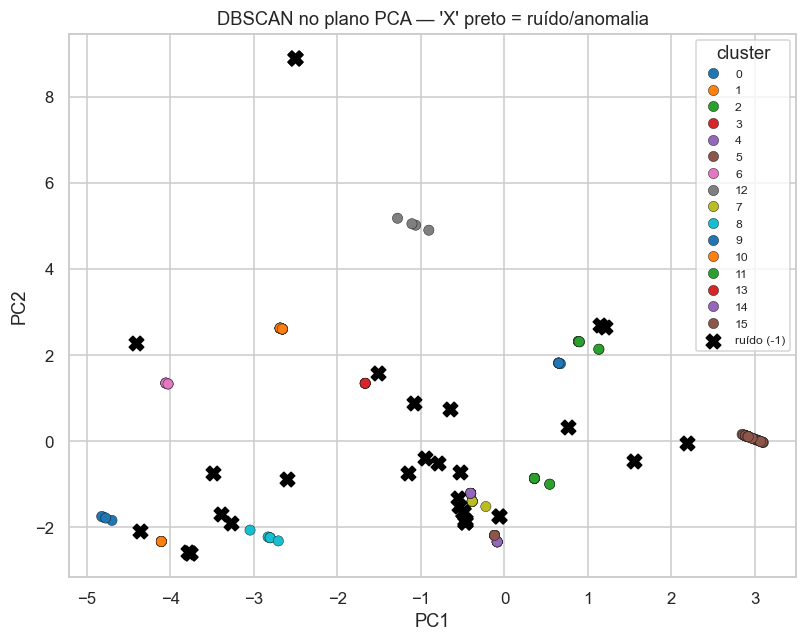

In [26]:
dbs = DBSCAN(eps=EPS, min_samples=min_samples).fit(Xp)
d["db"] = dbs.labels_
n_cl = len(set(dbs.labels_) - {-1}); n_noise = int((dbs.labels_ == -1).sum())
print(f"DBSCAN(eps={EPS}, min_samples={min_samples}) -> {n_cl} clusters + {n_noise} pontos de ruído "
      f"({n_noise / len(d) * 100:.1f}%)")

plt.figure(figsize=(7.5, 6))
mask = (d["db"] == -1).values
sns.scatterplot(x=X2[~mask, 0], y=X2[~mask, 1], hue=d.loc[~mask, "db"].astype(str),
                palette="tab10", s=45, edgecolor="k", linewidth=.3)
plt.scatter(X2[mask, 0], X2[mask, 1], c="black", marker="X", s=90, label="ruído (-1)")
plt.title("DBSCAN no plano PCA — 'X' preto = ruído/anomalia")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(title="cluster", fontsize=8)
plt.tight_layout(); plt.show()

In [27]:
print("=== Perfil dos clusters DBSCAN (-1 = ruído) ===")
display(perfil("db"))

print("\n=== Eventos marcados como RUÍDO pelo DBSCAN (candidatos a investigação) ===")
cols_show = ["Time", "Log comp", "Log subtype", "rule", "direction", "Src IP", "Dst IP",
             "Src port", "Dst port", "protocol", "Message"]
display(d.loc[d["db"] == -1, cols_show].sort_values("Time"))

=== Perfil dos clusters DBSCAN (-1 = ruído) ===


,n,%,regra_dominante,direcao_dominante,servico_dominante,proto_dominante,nat,src_net_dominante,n_src_ips,n_dst_ips,n_negados
db,,,,,,,,,,,
-1,36,18.0,WindowsUpdate-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,12,18,4
0,4,2.0,WebNat,Port2->Port3,HTTPS,TCP,DNAT,45.147.66.0/24,1,1,0
1,15,7.5,DMZ-to-WAN,Port3->Port2,HTTPS,TCP,SNAT,172.17.17.0/24,2,1,0
2,10,5.0,LAN-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,2,7,0
3,5,2.5,DMZ-to-WAN,Port3->Port2,HTTPS,TCP,SNAT,172.17.17.0/24,1,4,0
4,12,6.0,IT-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,1,11,0
5,59,29.5,LAN-2-WAN,Port1->Port2,DNS,UDP,SNAT,192.168.61.0/24,3,1,0
6,5,2.5,PALCERT_Outbound,Port3->Port2,HTTPS,TCP,NONE,172.17.17.0/24,2,1,0
7,10,5.0,WindowsUpdate-2-WAN,Port1->Port2,HTTPS,TCP,SNAT,192.168.61.0/24,2,9,0



=== Eventos marcados como RUÍDO pelo DBSCAN (candidatos a investigação) ===


,Time,Log comp,Log subtype,rule,direction,Src IP,Dst IP,Src port,Dst port,protocol,Message
199,2024-07-06 12:24:56,Firewall Rule,Allowed,FileShare-to-WAN,Port3->Port2,172.17.17.130,52.168.117.168,62160,443,TCP,NaN
197,2024-07-06 12:24:56,Firewall Rule,Allowed,WebNat,Port2->Port3,46.43.67.73,82.213.48.193,39156,443,TCP,NaN
192,2024-07-06 12:25:05,Firewall Rule,Allowed,WindowsUpdate-2-WAN,Port1->Port2,192.168.61.233,52.113.194.132,54547,443,TCP,NaN
189,2024-07-06 12:25:13,Invalid Traffic,Denied,NONE,NONE->NONE,159.192.104.79,213.6.25.178,63228,1078,TCP,TCP Packets with invalid flag combination.
187,2024-07-06 12:25:16,Firewall Rule,Allowed,FileShare-to-WAN,Port3->Port2,172.17.17.130,20.101.57.9,123,123,UDP,NaN
186,2024-07-06 12:25:16,Firewall Rule,Allowed,WindowsUpdate-2-WAN,Port1->Port2,192.168.61.233,52.113.194.132,54548,443,TCP,NaN
184,2024-07-06 12:25:17,Firewall Rule,Allowed,FileShare-to-WAN,Port3->Port2,172.17.17.130,8.8.8.8,62769,53,UDP,NaN
183,2024-07-06 12:25:17,Firewall Rule,Allowed,WebNat,Port2->Port3,104.28.62.95,82.213.48.193,26823,80,TCP,NaN
176,2024-07-06 12:25:25,Firewall Rule,Allowed,IT-2-WAN,Port1->Port2,192.168.61.233,52.168.117.175,54571,443,TCP,NaN
173,2024-07-06 12:25:29,Firewall Rule,Denied,BlockedIP,Port1->NONE,192.168.61.233,82.213.6.150,54592,80,TCP,NaN


**Resultado de segurança:** o conjunto de ruído contém **os 4 eventos negados do dataset** — os dois
`Invalid Traffic` (cabeçalho IP inválido e combinação de flags TCP inválida, típica de *scan*) e os dois
bloqueios da regra `BlockedIP` — além de eventos operacionalmente raros que merecem verificação: DNS **sobre
TCP** para um resolvedor externo (`192.168.61.201 → 213.244.72.31:53`), Teredo (`udp/3544`), o DNAT de entrada
`WAN-2-DNS-DNAT` e acessos isolados do servidor de arquivos à Internet.

Vale destacar o que isso significa: **nenhum rótulo foi usado** em nenhuma etapa. O fato de todos os eventos
negados caírem no ruído é uma validação *a posteriori* de que a densidade no espaço de atributos captura a
noção de "evento atípico" — mas é preciso registrar que o ruído tem 36 eventos, ou seja, a precisão como
detector de anomalia é baixa (4/36); ele funciona como **filtro de triagem**, reduzindo 200 eventos a 36 para
inspeção humana, não como classificador.

## 9. Avaliação de clusters

Sem rótulos verdadeiros, usamos **índices internos** e **concordância entre algoritmos**:

- **Silhouette** ∈ [-1,1] — coesão vs. separação (maior é melhor);
- **Davies-Bouldin** ≥ 0 — razão dispersão/separação (menor é melhor);
- **Calinski-Harabasz** — razão de variância entre/intra grupos (maior é melhor);
- **ARI / NMI** — concordância entre duas partições; alta concordância entre métodos de princípios diferentes
  é evidência de que a estrutura é real, e não artefato do algoritmo.

In [28]:
def avalia(nome, labels, Xm=Xp):
    labels = np.asarray(labels)
    m = labels != -1
    k = len(set(labels[m]))
    if k < 2:
        return {"algoritmo": nome, "n_clusters": k, "silhouette": np.nan, "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan, "%_ruido": round((~m).mean() * 100, 1)}
    return {"algoritmo": nome, "n_clusters": k,
            "silhouette": round(silhouette_score(Xm[m], labels[m]), 3),
            "davies_bouldin": round(davies_bouldin_score(Xm[m], labels[m]), 3),
            "calinski_harabasz": round(calinski_harabasz_score(Xm[m], labels[m]), 1),
            "%_ruido": round((~m).mean() * 100, 1)}

aval = pd.DataFrame([
    avalia(f"K-Means (k={K_BEST})", d["km"]),
    avalia(f"Hierárquico Ward (k={K_BEST})", d["hc"]),
    avalia(f"DBSCAN (eps={EPS})", d["db"]),
]).set_index("algoritmo")
display(aval)

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,%_ruido
algoritmo,,,,,
K-Means (k=7),7,0.437,1.021,36.8,0.0
Hierárquico Ward (k=7),7,0.420,1.224,36.3,0.0
DBSCAN (eps=0.778),16,0.958,0.075,6923.9,18.0


> **Atenção à comparação:** o DBSCAN aparece com Silhouette e Calinski-Harabasz muito superiores, mas a
> comparação **não é direta**. Os índices do DBSCAN são calculados **excluindo os 18% de pontos classificados
> como ruído** — justamente os mais difíceis de agrupar —, enquanto K-Means e Hierárquico são obrigados a
> classificar 100% das amostras. Além disso o DBSCAN encontrou mais clusters (16 contra 7), e o Silhouette
> favorece partições mais finas neste espaço, como já discutido na seção do K-Means. A leitura correta é:
> cada algoritmo responde a uma pergunta diferente — particionar todo o tráfego (K-Means/Ward) vs. identificar
> núcleos densos e descartar o resto (DBSCAN) — e não há um "vencedor" único.

In [29]:
# Concordância entre partições
pares = [("km", "hc"), ("km", "db"), ("hc", "db")]
conc = pd.DataFrame([{"par": f"{a} vs {b}",
                      "ARI": round(adjusted_rand_score(d[a], d[b]), 3),
                      "NMI": round(normalized_mutual_info_score(d[a], d[b]), 3)}
                     for a, b in pares]).set_index("par")
display(conc)

# Coerência "externa" de sanidade: os clusters reproduzem a regra de firewall aplicada?
for col, nome in [("km", "K-Means"), ("hc", "Hierárquico"), ("db", "DBSCAN")]:
    print(f"{nome:12s} vs 'Firewall rule name' -> ARI={adjusted_rand_score(d['rule'], d[col]):.3f} "
          f"| NMI={normalized_mutual_info_score(d['rule'], d[col]):.3f}")

,ARI,NMI
par,,
km vs hc,0.797,0.809
km vs db,0.460,0.649
hc vs db,0.539,0.670


K-Means      vs 'Firewall rule name' -> ARI=0.551 | NMI=0.683
Hierárquico  vs 'Firewall rule name' -> ARI=0.653 | NMI=0.756
DBSCAN       vs 'Firewall rule name' -> ARI=0.582 | NMI=0.715


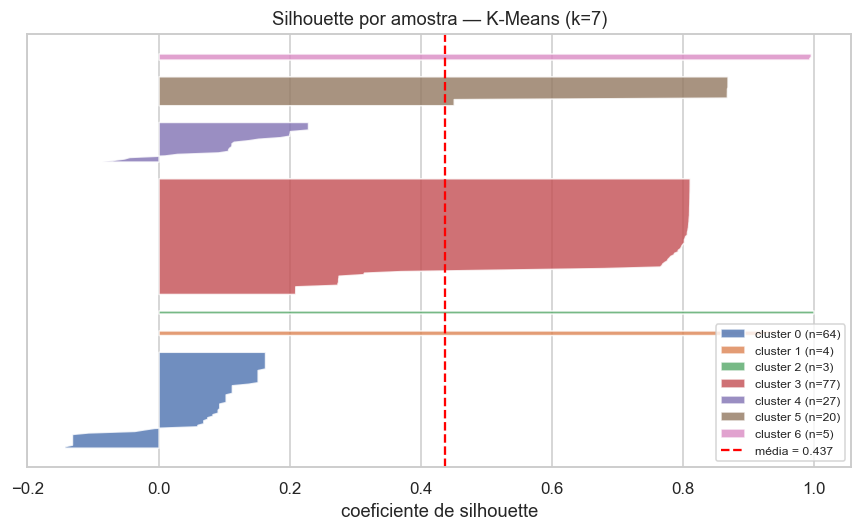

Silhouette médio por cluster:
0    0.070
1    0.938
2    1.000
3    0.684
4    0.122
5    0.763
6    0.994


In [30]:
# Silhouette plot detalhado do K-Means
sv = silhouette_samples(Xp, d["km"])
plt.figure(figsize=(8, 5))
y0 = 10
for i in sorted(d["km"].unique()):
    v = np.sort(sv[d["km"] == i])
    plt.fill_betweenx(np.arange(y0, y0 + len(v)), 0, v, alpha=.8, label=f"cluster {i} (n={len(v)})")
    y0 += len(v) + 10
plt.axvline(sv.mean(), color="red", ls="--", label=f"média = {sv.mean():.3f}")
plt.title(f"Silhouette por amostra — K-Means (k={K_BEST})")
plt.xlabel("coeficiente de silhouette"); plt.yticks([]); plt.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("Silhouette médio por cluster:")
print(pd.Series(sv).groupby(d["km"].values).mean().round(3).to_string())

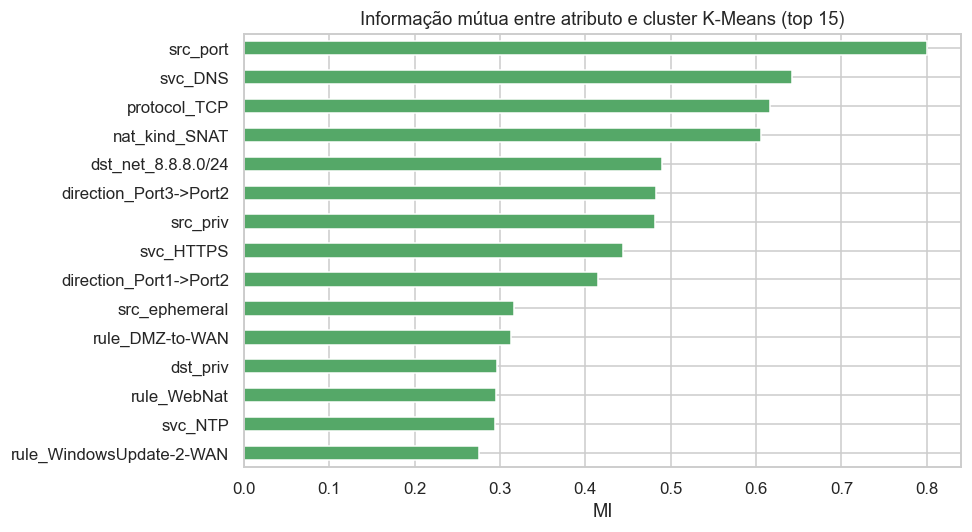

Atributos irrelevantes para a partição (MI ~ 0): ['dst_net_52.113.194.0/24', 'dst_net_52.168.117.0/24']


In [31]:
# Relevância dos atributos para a partição final (informação mútua)
mi = mutual_info_classif(X_sel, d["km"], random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
mi_s.head(15).sort_values().plot.barh(color="#55A868")
plt.title("Informação mútua entre atributo e cluster K-Means (top 15)")
plt.xlabel("MI"); plt.tight_layout(); plt.show()
print("Atributos irrelevantes para a partição (MI ~ 0):", list(mi_s[mi_s < 1e-3].index))

## 10. t-SNE

**Justificativa:** o PCA é linear e, num espaço *one-hot*, pode sobrepor grupos distintos nos dois primeiros
eixos. O t-SNE preserva **vizinhanças locais** e serve como verificação visual independente da partição.
Como é estocástico e sensível à `perplexity`, testamos vários valores (a geometria global do t-SNE não deve
ser interpretada como distância real).

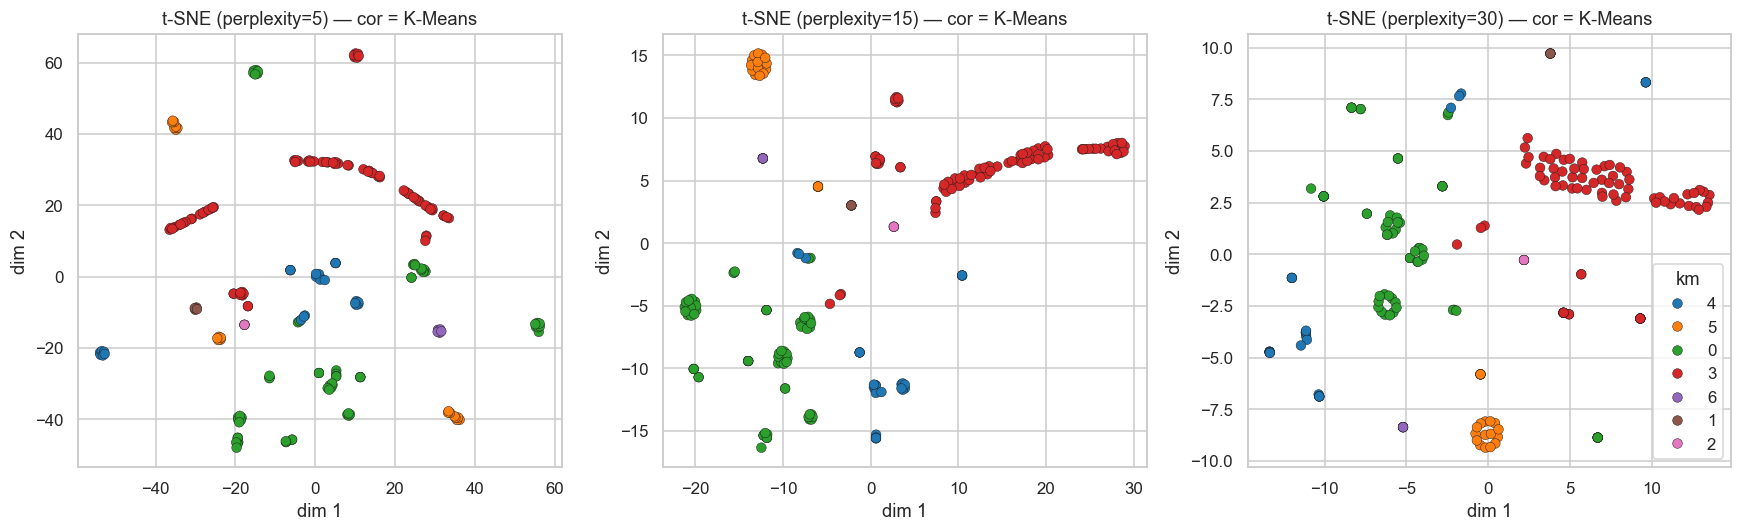

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, perp in zip(ax, [5, 15, 30]):
    Xt_ = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto",
               random_state=RANDOM_STATE).fit_transform(Xp)
    sns.scatterplot(x=Xt_[:, 0], y=Xt_[:, 1], hue=d["km"].astype(str), palette="tab10",
                    s=40, edgecolor="k", linewidth=.3, ax=a, legend=(perp == 30))
    a.set_title(f"t-SNE (perplexity={perp}) — cor = K-Means")
    a.set_xlabel("dim 1"); a.set_ylabel("dim 2")
plt.tight_layout(); plt.show()

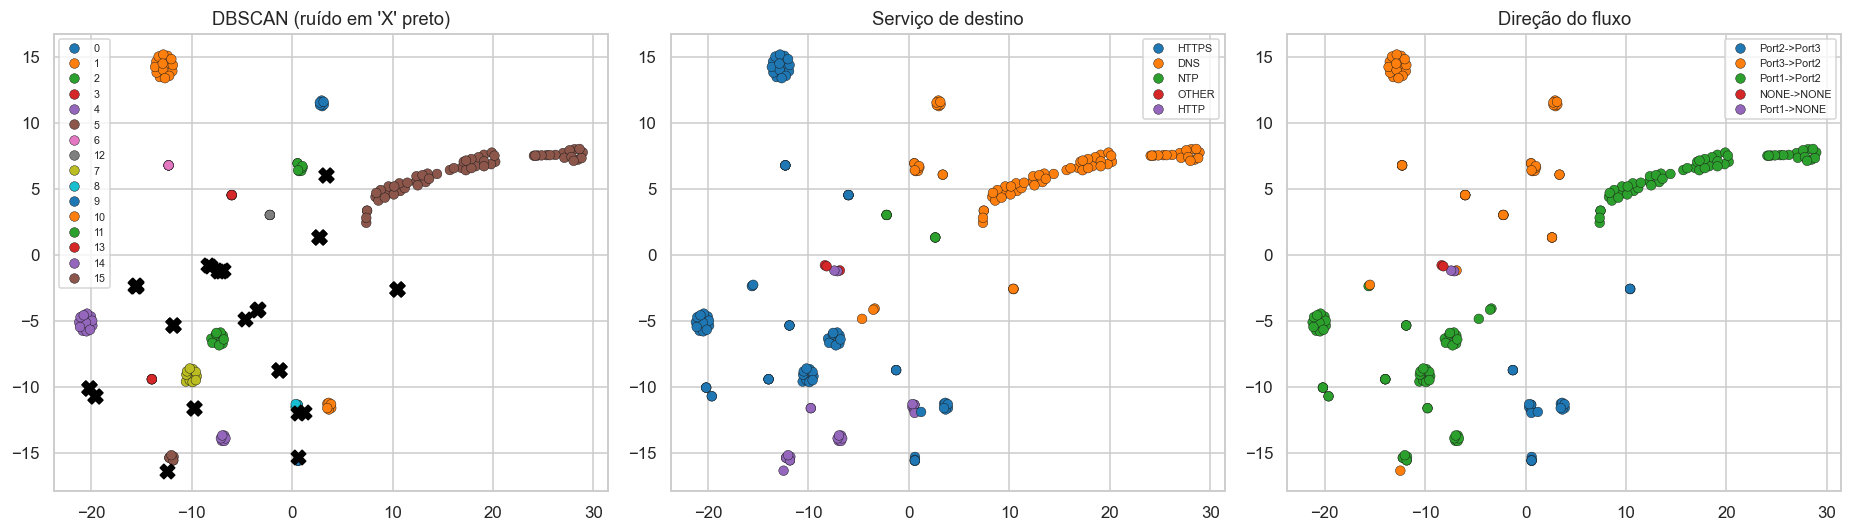

In [33]:
Xt = TSNE(n_components=2, perplexity=15, init="pca", learning_rate="auto",
          random_state=RANDOM_STATE).fit_transform(Xp)
d["tsne1"], d["tsne2"] = Xt[:, 0], Xt[:, 1]

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, (col, tit) in zip(ax, [("db", "DBSCAN (ruído em 'X' preto)"),
                              ("svc", "Serviço de destino"),
                              ("direction", "Direção do fluxo")]):
    if col == "db":
        m = (d["db"] == -1).values
        sns.scatterplot(x=Xt[~m, 0], y=Xt[~m, 1], hue=d.loc[~m, "db"].astype(str),
                        palette="tab10", s=40, edgecolor="k", linewidth=.3, ax=a)
        a.scatter(Xt[m, 0], Xt[m, 1], c="black", marker="X", s=90)
    else:
        sns.scatterplot(x=Xt[:, 0], y=Xt[:, 1], hue=d[col], palette="tab10",
                        s=40, edgecolor="k", linewidth=.3, ax=a)
    a.set_title(tit); a.legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()

**Leitura:** o t-SNE mostra ilhas bem separadas que coincidem com combinações *segmento × serviço*
(LAN→WAN/DNS, LAN→WAN/HTTPS de Windows Update, DMZ→WAN, WAN→DMZ com DNAT do web server). Os pontos de ruído do
DBSCAN aparecem isolados ou nas bordas — coerente com a interpretação de anomalia.

## 11. Regras de associação: Apriori e FP-Growth

**Justificativa:** clusters dizem *quais* eventos se parecem, mas não *por que* em linguagem de política de
firewall. Regras de associação produzem afirmações auditáveis do tipo
`{in=Port1, proto=UDP} => {svc=DNS}`. Cada log vira uma **transação** com os itens categóricos do evento.

**Métricas:** *support* (frequência), *confidence* (P(consequente | antecedente)) e *lift* (>1 indica associação
acima do esperado por independência). Apriori e FP-Growth resolvem o **mesmo** problema (itemsets frequentes),
diferindo no algoritmo: Apriori faz varreduras sucessivas gerando candidatos; FP-Growth constrói uma FP-tree e
não gera candidatos, sendo normalmente mais rápido. Comparamos resultados e tempos.

**Controle da explosão combinatória.** Uma primeira execução com o vocabulário completo (incluindo `comp`,
`dport`, `in`, `out` e `src_port`) gerou **22 431 itemsets e ~1,4 milhão de regras** — inútil para leitura
humana. A causa é a redundância entre itens (`dport=53` ≡ `svc=DNS`; `in`+`out` ≡ `dir`) somada a itens
quase universais (`comp=Firewall Rule` com suporte 0,99), que se combinam com tudo. Corrigimos com três
medidas metodológicas:

1. **vocabulário não redundante**: `dir` substitui `in`+`out`; `svc` substitui `dport`; `comp` e `src_port`
   são removidos por serem quase constantes (não discriminam nada);
2. **`max_len = 3`**, limitando itemsets a 3 itens — regras mais longas são especializações redundantes;
3. na apresentação, apenas regras com **consequente de 1 item** e `lift > 1,2`.

In [34]:
def transacao(r):
    return [f"action={r['Log subtype']}", f"rule={r['rule']}", f"nat={r['nat_kind']}",
            f"dir={r['direction']}", f"proto={r['protocol']}", f"svc={r['svc']}",
            f"srcnet={r['src_net']}", f"dst_priv={'yes' if r['dst_priv'] else 'no'}"]

trans = d.apply(transacao, axis=1).tolist()
te = TransactionEncoder()
T = pd.DataFrame(te.fit_transform(trans), columns=te.columns_)
print("Matriz de transações:", T.shape, "| itens distintos:", len(te.columns_))
print("\nExemplo de transação:", trans[0])
T.head(3)

Matriz de transações: (200, 45) | itens distintos: 45

Exemplo de transação: ['action=Allowed', 'rule=WebNat', 'nat=DNAT', 'dir=Port2->Port3', 'proto=TCP', 'svc=HTTPS', 'srcnet=45.147.66.0/24', 'dst_priv=no']


,action=Allowed,action=Denied,dir=NONE->NONE,dir=Port1->NONE,dir=Port1->Port2,dir=Port2->Port3,dir=Port3->Port2,dst_priv=no,dst_priv=yes,nat=DNAT,...,srcnet=45.147.66.0/24,srcnet=46.43.67.0/24,srcnet=77.91.170.0/24,srcnet=82.213.1.0/24,srcnet=91.218.152.0/24,svc=DNS,svc=HTTP,svc=HTTPS,svc=NTP,svc=OTHER
0,True,False,False,False,False,True,False,True,False,True,...,True,False,False,False,False,False,False,True,False,False
1,True,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,True,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [35]:
import time
MIN_SUP, MAX_LEN = 0.05, 3

t0 = time.perf_counter()
fi_ap = apriori(T, min_support=MIN_SUP, use_colnames=True, max_len=MAX_LEN)
t_ap = time.perf_counter() - t0
t0 = time.perf_counter()
fi_fp = fpgrowth(T, min_support=MIN_SUP, use_colnames=True, max_len=MAX_LEN)
t_fp = time.perf_counter() - t0

print(f"Apriori  : {len(fi_ap)} itemsets frequentes em {t_ap*1000:.1f} ms")
print(f"FP-Growth: {len(fi_fp)} itemsets frequentes em {t_fp*1000:.1f} ms")

norm = lambda df_: set(map(frozenset, df_["itemsets"]))
print("\nOs dois algoritmos produzem exatamente o mesmo conjunto de itemsets?", norm(fi_ap) == norm(fi_fp))

fi_ap["tamanho"] = fi_ap["itemsets"].apply(len)
print("\nItemsets frequentes por tamanho:")
print(fi_ap["tamanho"].value_counts().sort_index().to_string())

print("\nTop 15 itemsets frequentes:")
display(fi_ap.sort_values("support", ascending=False).head(15)
        .assign(itemsets=lambda x: x["itemsets"].apply(lambda s: ", ".join(sorted(s)))))

Apriori  : 395 itemsets frequentes em 2.2 ms
FP-Growth: 395 itemsets frequentes em 2.4 ms

Os dois algoritmos produzem exatamente o mesmo conjunto de itemsets? True

Itemsets frequentes por tamanho:
tamanho
1     20
2    107
3    268

Top 15 itemsets frequentes:


,support,itemsets,tamanho
0,0.980,action=Allowed,1
4,0.895,dst_priv=no,1
23,0.875,"action=Allowed, dst_priv=no",2
7,0.840,nat=SNAT,1
26,0.835,"action=Allowed, nat=SNAT",2
65,0.760,"dst_priv=no, nat=SNAT",2
153,0.755,"action=Allowed, dst_priv=no, nat=SNAT",3
16,0.620,srcnet=192.168.61.0/24,1
93,0.615,"nat=SNAT, srcnet=192.168.61.0/24",2
74,0.615,"dst_priv=no, srcnet=192.168.61.0/24",2


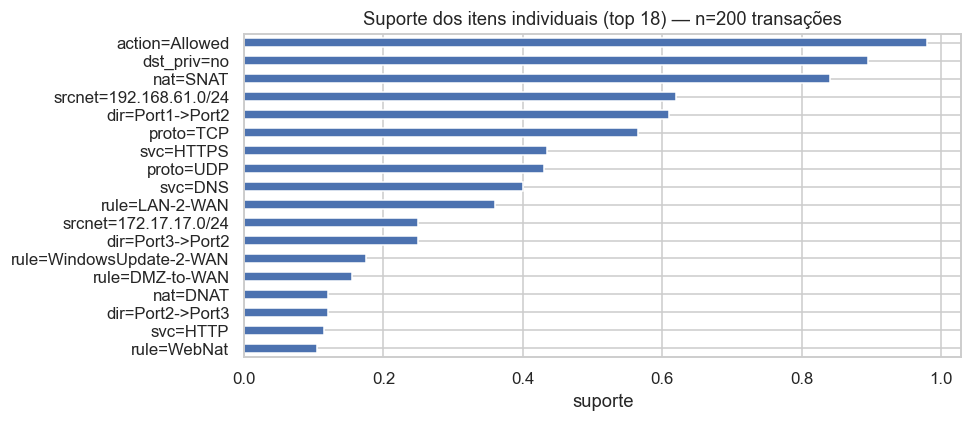

In [36]:
plt.figure(figsize=(9, 4))
T.mean().sort_values(ascending=False).head(18).sort_values().plot.barh(color="#4C72B0")
plt.title(f"Suporte dos itens individuais (top 18) — n={len(T)} transações")
plt.xlabel("suporte"); plt.tight_layout(); plt.show()

In [37]:
rules = association_rules(fi_ap, metric="confidence", min_threshold=0.8)
rules["n_cons"] = rules["consequents"].apply(len)
rules["antecedents"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))

# Regras interessantes: consequente único e lift acima do trivial
interessantes = (rules[(rules["lift"] > 1.2) & (rules["n_cons"] == 1)]
                 .sort_values(["lift", "confidence", "support"], ascending=False)
                 [["antecedents", "consequents", "support", "confidence", "lift", "leverage"]].round(3))
print(f"Total de regras (confiança >= 0.8): {len(rules)} | "
      f"com consequente único e lift > 1.2: {len(interessantes)}")
display(interessantes.head(25))

Total de regras (confiança >= 0.8): 657 | com consequente único e lift > 1.2: 258


,antecedents,consequents,support,confidence,lift,leverage
399,"dir=Port2->Port3, proto=TCP",rule=WebNat,0.105,1.0,9.524,0.094
552,"nat=DNAT, proto=TCP",rule=WebNat,0.105,1.0,9.524,0.094
404,"dir=Port2->Port3, svc=HTTPS",rule=WebNat,0.075,1.0,9.524,0.067
557,"nat=DNAT, svc=HTTPS",rule=WebNat,0.075,1.0,9.524,0.067
29,dir=Port2->Port3,nat=DNAT,0.120,1.0,8.333,0.106
30,nat=DNAT,dir=Port2->Port3,0.120,1.0,8.333,0.106
107,"action=Allowed, dir=Port2->Port3",nat=DNAT,0.120,1.0,8.333,0.106
108,"action=Allowed, nat=DNAT",dir=Port2->Port3,0.120,1.0,8.333,0.106
371,"dir=Port2->Port3, dst_priv=no",nat=DNAT,0.120,1.0,8.333,0.106
372,"dst_priv=no, nat=DNAT",dir=Port2->Port3,0.120,1.0,8.333,0.106


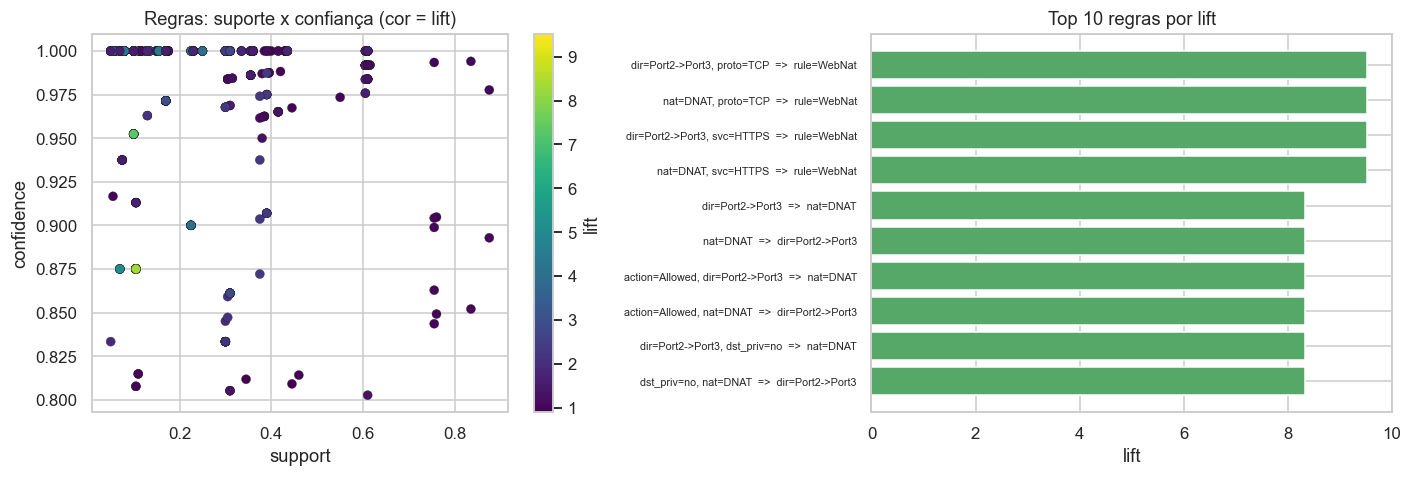

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sc = ax[0].scatter(rules["support"], rules["confidence"], c=rules["lift"],
                   cmap="viridis", s=35, edgecolor="k", linewidth=.2)
ax[0].set_xlabel("support"); ax[0].set_ylabel("confidence")
ax[0].set_title("Regras: suporte x confiança (cor = lift)")
plt.colorbar(sc, ax=ax[0], label="lift")

top10 = interessantes.head(10).iloc[::-1]
lbl = top10["antecedents"] + "  =>  " + top10["consequents"]
ax[1].barh(range(len(top10)), top10["lift"], color="#55A868")
ax[1].set_yticks(range(len(top10))); ax[1].set_yticklabels(lbl, fontsize=7)
ax[1].set_xlabel("lift"); ax[1].set_title("Top 10 regras por lift")
plt.tight_layout(); plt.show()

In [39]:
print("Regras que descrevem o acesso ao web server publicado (DNAT):")
display(rules[(rules["consequents"] == "nat=DNAT") & (rules["lift"] > 1.2)]
        [["antecedents", "consequents", "support", "confidence", "lift"]]
        .sort_values("support", ascending=False).round(3).head(10))

print("\nRegras que caracterizam o serviço a partir da rota:")
display(rules[(rules["consequents"].str.startswith("svc=")) & (rules["lift"] > 1.2)]
        [["antecedents", "consequents", "support", "confidence", "lift"]]
        .sort_values("support", ascending=False).round(3).head(10))

Regras que descrevem o acesso ao web server publicado (DNAT):


,antecedents,consequents,support,confidence,lift
29,dir=Port2->Port3,nat=DNAT,0.120,1.0,8.333
107,"action=Allowed, dir=Port2->Port3",nat=DNAT,0.120,1.0,8.333
371,"dir=Port2->Port3, dst_priv=no",nat=DNAT,0.120,1.0,8.333
55,rule=WebNat,nat=DNAT,0.105,1.0,8.333
192,"action=Allowed, rule=WebNat",nat=DNAT,0.105,1.0,8.333
385,"dir=Port2->Port3, proto=TCP",nat=DNAT,0.105,1.0,8.333
389,"dir=Port2->Port3, rule=WebNat",nat=DNAT,0.105,1.0,8.333
454,"dst_priv=no, rule=WebNat",nat=DNAT,0.105,1.0,8.333
551,"proto=TCP, rule=WebNat",nat=DNAT,0.105,1.0,8.333
395,"dir=Port2->Port3, svc=HTTPS",nat=DNAT,0.075,1.0,8.333



Regras que caracterizam o serviço a partir da rota:


,antecedents,consequents,support,confidence,lift
71,proto=UDP,svc=DNS,0.390,0.907,2.267
250,"action=Allowed, proto=UDP",svc=DNS,0.390,0.907,2.267
504,"dst_priv=no, proto=UDP",svc=DNS,0.390,0.907,2.267
577,"nat=SNAT, proto=UDP",svc=DNS,0.375,0.904,2.259
267,"action=Allowed, rule=LAN-2-WAN",svc=DNS,0.310,0.861,2.153
77,rule=LAN-2-WAN,svc=DNS,0.310,0.861,2.153
354,"dir=Port1->Port2, rule=LAN-2-WAN",svc=DNS,0.310,0.861,2.153
595,"nat=SNAT, rule=LAN-2-WAN",svc=DNS,0.310,0.861,2.153
649,"rule=LAN-2-WAN, srcnet=192.168.61.0/24",svc=DNS,0.310,0.861,2.153
520,"dst_priv=no, rule=LAN-2-WAN",svc=DNS,0.305,0.859,2.148


### O limite do suporte diante de classes raras

Com `min_support = 0,05` **nenhuma** regra pode ter `action=Denied` no consequente: eventos negados têm suporte
de apenas 0,02 (4 em 200) e são eliminados na primeira poda do Apriori. Isso ilustra uma limitação central das
regras de associação em segurança — **o que interessa é raro justamente por ser anômalo**. Para tornar essas
regras visíveis é preciso baixar o suporte mínimo ao nível da própria classe rara, aceitando em troca regras
estatisticamente frágeis (apoiadas em 2–4 transações). Fazemos isso abaixo de forma explícita, como análise
complementar e **não** como evidência estatística.

In [40]:
fi_raro = apriori(T, min_support=0.01, use_colnames=True, max_len=3)
r_raro = association_rules(fi_raro, metric="confidence", min_threshold=0.6)
r_raro["n_cons"] = r_raro["consequents"].apply(len)
r_raro["antecedents"] = r_raro["antecedents"].apply(lambda s: ", ".join(sorted(s)))
r_raro["consequents"] = r_raro["consequents"].apply(lambda s: ", ".join(sorted(s)))

print(f"min_support=0.01 -> {len(fi_raro)} itemsets, {len(r_raro)} regras")
print("\nRegras cujo consequente é um evento NEGADO (suporte baixo, leitura qualitativa):")
display(r_raro[(r_raro["consequents"] == "action=Denied") & (r_raro["n_cons"] == 1)]
        [["antecedents", "consequents", "support", "confidence", "lift"]]
        .sort_values(["confidence", "lift"], ascending=False).round(3))

min_support=0.01 -> 880 itemsets, 2006 regras

Regras cujo consequente é um evento NEGADO (suporte baixo, leitura qualitativa):


,antecedents,consequents,support,confidence,lift
35,dir=NONE->NONE,action=Denied,0.010,1.000,50.000
36,dir=Port1->NONE,action=Denied,0.010,1.000,50.000
40,rule=BlockedIP,action=Denied,0.010,1.000,50.000
41,rule=NONE,action=Denied,0.010,1.000,50.000
711,"dir=NONE->NONE, dst_priv=no",action=Denied,0.010,1.000,50.000
714,"dir=NONE->NONE, nat=NONE",action=Denied,0.010,1.000,50.000
718,"dir=NONE->NONE, rule=NONE",action=Denied,0.010,1.000,50.000
723,"dir=NONE->NONE, svc=OTHER",action=Denied,0.010,1.000,50.000
728,"dir=Port1->NONE, dst_priv=no",action=Denied,0.010,1.000,50.000
731,"dir=Port1->NONE, proto=TCP",action=Denied,0.010,1.000,50.000


**Leitura:** `rule=BlockedIP ⇒ action=Denied` com confiança 1,0 e lift 50 é a tradução exata da política de
bloqueio configurada no firewall; `dir=NONE->NONE ⇒ action=Denied` identifica o tráfego descartado antes de
qualquer decisão de roteamento (os pacotes malformados). São regras corretas e úteis, mas sustentadas por
2 transações cada — daí a necessidade de interpretá-las qualitativamente.

### Comparação Apriori vs FP-Growth

| Critério | Apriori | FP-Growth |
|---|---|---|
| Estratégia | geração de candidatos + poda por antimonotonicidade | FP-tree compactada, crescimento de padrões |
| Varreduras da base | uma por nível de itemset | duas |
| Resultado | idêntico (verificado acima) | idêntico (verificado acima) |
| Desempenho | pior com suporte baixo / muitos itens | melhor (não gera candidatos) |

Com 200 transações e poucas dezenas de itens a diferença de tempo é irrelevante; a equivalência dos itemsets
confirmada acima é a garantia de corretude — em bases reais de log (milhões de eventos) a escolha recai sobre
FP-Growth.

---
## 12. Conclusões

**Sobre o dataset (2.a).** 200 eventos de firewall em ~5 minutos, extremamente concentrados: 98% `Allowed`,
três serviços (HTTPS/DNS/HTTP) respondendo por ~95% do tráfego e dois hosts por mais da metade dos eventos.
Quatro colunas não carregam informação alguma e os valores ausentes são estruturais (não aleatórios).

**Sobre as técnicas (2.b).**

1. **Seleção de características** foi indispensável: removeu 4 colunas vazias/constantes, 56 *dummies* de
   frequência desprezível e os atributos redundantes (|ρ|>0,95), levando a matriz de 101 para 37 dimensões. O
   atributo temporal `t_rel` foi deliberadamente excluído da métrica de distância, por injetar proximidade
   artificial e gerar efeitos de borda no DBSCAN — decisão verificada empiricamente.
2. **PCA** mostrou que a variância do log é dominada pelo par *segmento de rede × serviço* e forneceu o espaço
   reduzido (17 componentes, 90% da variância) em que a clusterização se tornou estável.
3. **K-Means** recuperou 7 perfis operacionais de tráfego diretamente interpretáveis: DNS interno da LAN
   (38,5%), Windows Update/HTTPS (32%), publicação do web server via DNAT (13,5%), DMZ→WAN HTTPS (10%), NTP da
   DMZ, NTP do file server e `PALCERT_Outbound`. A escolha de *k* exigiu cuidado metodológico: o Silhouette
   cresce monotonicamente neste espaço *one-hot*, de modo que a seleção foi feita pelo joelho da inércia, com
   os índices internos usados apenas como verificação. Limitação: o K-Means é obrigado a absorver eventos raros
   dentro de clusters normais.
4. **Hierárquico (Ward)** produziu partição fortemente concordante com o K-Means (ARI ≈ 0,80; NMI ≈ 0,81) e, via
   dendrograma, evidenciou a hierarquia dos perfis — a concordância entre dois métodos de princípios distintos é
   o principal indício de que a estrutura encontrada é real. O coeficiente cofenético mais alto de `average`
   não foi seguido, por produzir *chaining* e clusters inutilizáveis.
5. **DBSCAN** foi o algoritmo mais útil do ponto de vista de segurança: com 16 núcleos densos e 18% de ruído,
   colocou **os 4 eventos negados do dataset** no conjunto de ruído, junto de eventos operacionalmente raros
   (DNS sobre TCP para resolvedor externo, Teredo/3544, DNAT de entrada de DNS), **sem usar nenhum rótulo**.
   Funciona como filtro de triagem (200 → 36 eventos para inspeção), não como classificador.
6. **Avaliação de clusters** quantificou a qualidade por Silhouette, Davies-Bouldin e Calinski-Harabasz e a
   estabilidade por ARI/NMI. Registrou-se explicitamente que os índices do DBSCAN não são comparáveis aos dos
   outros dois, por serem calculados sem os pontos de ruído.
7. **t-SNE** confirmou visualmente a separação em ilhas correspondentes às combinações de rota e serviço, que o
   PCA linear apresentava parcialmente sobrepostas.
8. **Apriori/FP-Growth** traduziram a estrutura em regras legíveis sobre a política do firewall (UDP saindo pela
   LAN ⇒ DNS, conf. 0,91 / lift 2,27; entrada Port2→Port3 ⇒ DNAT, conf. 1,0 / lift 8,33), com **conjuntos de
   itemsets idênticos** entre os dois algoritmos e FP-Growth ~2x mais rápido. A execução inicial produziu 1,4
   milhão de regras: foi necessário eliminar itens redundantes e quase universais e limitar `max_len`, o que
   reduziu o resultado a 395 itemsets e 657 regras legíveis. Também se documentou que, com suporte mínimo de
   5%, **nenhuma** regra sobre eventos negados pode existir (suporte real de 2%) — limitação estrutural das
   regras de associação frente a classes raras.

**Limitações.** (i) A amostra é pequena (200 eventos, 5 minutos) e não cobre variação diurna; (ii) o
desbalanceamento extremo (4 eventos negados) impede qualquer validação estatística das anomalias detectadas;
(iii) o log não traz bytes/duração da conexão — atributos que, se disponíveis, melhorariam substancialmente a
caracterização de exfiltração e *beaconing*; (iv) índices internos de cluster são apenas indicativos em espaços
*one-hot*, onde a distância euclidiana é uma aproximação grosseira da dissimilaridade real (alternativas:
distância de Gower, k-modes).